# 03 — Representation Feature Diagnostics (Exploratory, Final Cohort)

> **Notebook role**: `EXPLORATORY / DIAGNOSTIC` — auxiliary track under `D-RD-04`.
> **This is NOT** `07_eda_and_decomposition.ipynb`. No claim is made that canonical NB07 has been
> performed, started, or superseded. Canonical figure IDs `F01`–`F09` (SSOT §16.2) are deliberately
> **not** used here; this notebook uses its own `D-xx` diagnostic panel numbering.

## Purpose

Give the Research Director a direct data-science view of the **final** Representation layer
(`REP_FEATURES_v001`, N = 3,835,988) so that distribution shape, boundaries, outliers, heavy tails,
paired KO/EN structure, heterogeneity, and redundancy can be inspected before any downstream
morphology or tokenizer population run is authorized.

## Authority

| Layer | Reference |
|---|---|
| 1 — SSOT | `KOEN-TP-RS-001` / `Korean_English_Tokenization_Premium_Research_Spec_v1.0` (§8, §12.2 D-02, §16, §31) |
| 2 — Director redline / decisions | `ssot/2026-08-16_1701_..._PRINTED_SSOT_REDLINE_AND_G1_TRAFFIC_CONTROL.md`, D-RD-01…D-RD-08 |
| 3 — Frozen contracts | `REPRESENTATION_CONFIG` (`src/tokenization_premium/representation.py`), ENG-OBS-001 |
| 4 — Handoff / operational | `outputs/manifests/REP_FEATURES_MANIFEST_v001.json` |
| 5 — Execution evidence | `ssot/HumanLebeled/KOEN_G1_HUMAN_AUDIT_FINAL_ADJUDICATION.md` (final cohort = 3,836,013 − 25) |

## Explicit non-claims

This notebook does **not**:

- constitute G2 / G5 PASS (collinearity findings here are **not** a G5 collinearity gate result);
- perform any tokenization, `TP` / `logTP` / compression-penalty measurement, or morphology analysis;
- perform any hypothesis test, bootstrap, or model fit;
- recompute, mutate, or re-version any canonical artifact;
- export raw KO/EN sentence text, previews, URLs, or PII (repository hygiene, OPS-DR-01 forward policy).

## Compute policy

- Full-population statistics: **DuckDB with Parquet projection/predicate pushdown**. The
  3,835,988 × 47 table is never loaded into Pandas in one piece.
- Plotting and rank correlation: **deterministic bounded sample** keyed on
  `md5(pair_id || 'REP_EDA_v001')` — reproducible without relying on file/row order.
- DuckDB memory limit is set from *actually observed* available RAM; spill is mandatory
  (`.runtime/rep-eda/duckdb-spill`). One heavy WSL job at a time.

## 0 — Pre-execution resource snapshot (ENG-OBS-001 §10)

In [1]:
from __future__ import annotations

import json
import platform
import shutil
import subprocess
import sys
import time
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import duckdb
import numpy as np
import pandas as pd
import psutil

from tokenization_premium.hashing import sha256_file
from tokenization_premium.paths import PROJECT_ROOT

KST = ZoneInfo("Asia/Seoul")
RUN_ID = "REP_EDA_20260817"
EDA_RUNTIME = PROJECT_ROOT / ".runtime" / "rep-eda"
SPILL_DIR = EDA_RUNTIME / "duckdb-spill"
SPILL_DIR.mkdir(parents=True, exist_ok=True)


def resource_snapshot(label: str) -> dict:
    '실제 관측된 CPU/RAM/disk/GPU 상태를 dict로 반환한다 (추정값을 쓰지 않는다).'
    vm = psutil.virtual_memory()
    du = shutil.disk_usage(PROJECT_ROOT)
    gpu = None
    try:
        out = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,utilization.gpu",
             "--format=csv,noheader,nounits"],
            capture_output=True, text=True, timeout=15)
        if out.returncode == 0 and out.stdout.strip():
            name, tot, used, util = (x.strip() for x in out.stdout.strip().splitlines()[0].split(","))
            gpu = {"name": name, "vram_total_mib": int(tot), "vram_used_mib": int(used),
                   "utilization_pct": int(util)}
    except (OSError, subprocess.SubprocessError, ValueError):
        gpu = None
    return {
        "label": label,
        "timestamp_kst": datetime.now(KST).isoformat(timespec="seconds"),
        "cpu_physical": psutil.cpu_count(logical=False),
        "cpu_logical": psutil.cpu_count(logical=True),
        "ram_total_gib": round(vm.total / 2**30, 2),
        "ram_available_gib": round(vm.available / 2**30, 2),
        "swap_total_gib": round(psutil.swap_memory().total / 2**30, 2),
        "disk_free_gib": round(du.free / 2**30, 1),
        "gpu": gpu,
    }


def resource_verdict(available_gib: float) -> str:
    'ENG-OBS-001 §10 및 directive 기준으로 자원 상태를 등급화한다.'
    if available_gib < 2:
        return "MEMORY_CRITICAL"
    if available_gib < 3:
        return "RESOURCE_UNSAFE"
    if available_gib < 6:
        return "RESOURCE_CONSTRAINED"
    return "RESOURCE_OK"


PRE = resource_snapshot("pre_eda")
VERDICT = resource_verdict(PRE["ram_available_gib"])

# DuckDB memory limit은 실제 available RAM에 맞춰 보수적으로 정한다 (고정 상수를 쓰지 않는다).
DUCKDB_MEM_GIB = max(2, min(6, int(PRE["ram_available_gib"] * 0.5)))
DUCKDB_THREADS = max(2, min(8, (PRE["cpu_logical"] or 4) // 3))

print(f"python           {platform.python_version()}   duckdb {duckdb.__version__}")
print(f"CPU              physical={PRE['cpu_physical']} logical={PRE['cpu_logical']}")
print(f"RAM              total={PRE['ram_total_gib']} GiB  available={PRE['ram_available_gib']} GiB"
      f"  swap={PRE['swap_total_gib']} GiB")
print(f"disk free        {PRE['disk_free_gib']} GiB")
print(f"GPU              {PRE['gpu']}")
print(f"RESOURCE VERDICT {VERDICT}")
print(f"DuckDB budget    memory_limit={DUCKDB_MEM_GIB}GB threads={DUCKDB_THREADS} "
      f"spill={SPILL_DIR.relative_to(PROJECT_ROOT)}")
assert VERDICT in {"RESOURCE_OK", "RESOURCE_CONSTRAINED"}, f"unsafe to run EDA: {VERDICT}"

python           3.12.3   duckdb 1.5.5
CPU              physical=24 logical=24
RAM              total=15.34 GiB  available=10.64 GiB  swap=4.0 GiB
disk free        683.4 GiB
GPU              {'name': 'NVIDIA GeForce RTX 5070 Ti Laptop GPU', 'vram_total_mib': 12227, 'vram_used_mib': 953, 'utilization_pct': 5}
RESOURCE VERDICT RESOURCE_OK
DuckDB budget    memory_limit=5GB threads=8 spill=.runtime/rep-eda/duckdb-spill


GPU is detected and reported for completeness only. This EDA is a columnar-scan / rank-statistics
workload; it is **not** forced onto the GPU, and no RAPIDS or other GPU dependency is installed.

## 1 — Input integrity re-verification (no recomputation)

In [2]:
REP_PATH = PROJECT_ROOT / "data" / "registry" / "REP_FEATURES_v001.parquet"
PAIR_PATH = PROJECT_ROOT / "data" / "registry" / "PAIR_REGISTRY_v002.parquet"
REP_MANIFEST = PROJECT_ROOT / "outputs" / "manifests" / "REP_FEATURES_MANIFEST_v001.json"
ADJUDICATION = PROJECT_ROOT / "ssot" / "HumanLebeled" / "KOEN_G1_HUMAN_AUDIT_FINAL_ADJUDICATION.md"

EXPECTED = {
    "REP_FEATURES_v001.parquet": "335c20deacb355dc1ca147547ae18e1a5ab1508fe5272508b62ee04ddf819e45",
    "PAIR_REGISTRY_v002.parquet": "95f523d11b0e8fcfd761dee949f082e9b4590b919801441fbcfa3426010bec52",
}
EXPECTED_N, EXPECTED_COLS = 3_835_988, 47

manifest = json.loads(REP_MANIFEST.read_text(encoding="utf-8"))
integrity = {}
for path in (REP_PATH, PAIR_PATH):
    actual = sha256_file(path)
    expected = EXPECTED[path.name]
    integrity[path.name] = {"sha256": actual, "match": actual == expected}
    print(f"{path.name:28s} {'PASS' if actual == expected else 'FAIL'}  {actual}")

assert all(v["match"] for v in integrity.values()), "input artifact hash mismatch — halt"
assert manifest["g1_final_cohort_application"]["post_exclusion_sha256"] == integrity[
    "REP_FEATURES_v001.parquet"]["sha256"], "manifest/artifact hash inconsistency"
print(f"\nmanifest post_exclusion_row_count = "
      f"{manifest['g1_final_cohort_application']['post_exclusion_row_count']:,}")
print(f"manifest excluded_pair_id_count   = "
      f"{manifest['g1_final_cohort_application']['excluded_pair_id_count']}")

REP_FEATURES_v001.parquet    PASS  335c20deacb355dc1ca147547ae18e1a5ab1508fe5272508b62ee04ddf819e45


PAIR_REGISTRY_v002.parquet   PASS  95f523d11b0e8fcfd761dee949f082e9b4590b919801441fbcfa3426010bec52

manifest post_exclusion_row_count = 3,835,988
manifest excluded_pair_id_count   = 25


In [3]:
con = duckdb.connect()
con.execute(f"SET memory_limit='{DUCKDB_MEM_GIB}GB'")
con.execute(f"SET threads={DUCKDB_THREADS}")
con.execute(f"SET temp_directory='{SPILL_DIR.as_posix()}'")
con.execute("SET preserve_insertion_order=false")
REP = f"read_parquet('{REP_PATH.as_posix()}')"

schema = con.execute(f"DESCRIBE SELECT * FROM {REP}").fetchdf()
COLUMNS = list(schema["column_name"])
n_rows, n_distinct, n_null_id = con.execute(
    f"SELECT COUNT(*), COUNT(DISTINCT pair_id), SUM((pair_id IS NULL)::INT) FROM {REP}").fetchone()

import re as _re
excluded_ids = sorted(set(_re.findall(r"pair_[0-9a-f]{64}", ADJUDICATION.read_text(encoding="utf-8"))))
con.execute("CREATE OR REPLACE TEMP TABLE excluded(pair_id VARCHAR)")
con.executemany("INSERT INTO excluded VALUES (?)", [(i,) for i in excluded_ids])
n_excluded_present = con.execute(
    f"SELECT COUNT(*) FROM {REP} r JOIN excluded e USING (pair_id)").fetchone()[0]

print(f"row_count                 {n_rows:,}      (expected {EXPECTED_N:,})")
print(f"distinct pair_id          {n_distinct:,}      (must equal row_count)")
print(f"null pair_id              {n_null_id}")
print(f"column_count              {len(COLUMNS)}            (expected {EXPECTED_COLS})")
print(f"G1-excluded ids parsed    {len(excluded_ids)}")
print(f"G1-excluded still present {n_excluded_present}            (must be 0)")

assert (n_rows, n_distinct, len(COLUMNS)) == (EXPECTED_N, EXPECTED_N, EXPECTED_COLS)
assert n_null_id == 0 and len(excluded_ids) == 25 and n_excluded_present == 0
print("\nINPUT_INTEGRITY = PASS — full recomputation is prohibited and not performed.")

row_count                 3,835,988      (expected 3,835,988)
distinct pair_id          3,835,988      (must equal row_count)
null pair_id              0
column_count              47            (expected 47)
G1-excluded ids parsed    25
G1-excluded still present 0            (must be 0)

INPUT_INTEGRITY = PASS — full recomputation is prohibited and not performed.


### Feature families under diagnosis

`pair_id` + 4 provenance columns + 42 numeric/boolean features. The provenance columns
(`feature_extractor_version`, `unicode_version`, `grapheme_implementation`, `config_sha256`)
are constants carried per row and are checked for nullity only.

In [4]:
SIDES = ["ko", "en"]
PER_SIDE = ["codepoint_count", "grapheme_count", "utf8_bytes", "bytes_per_codepoint",
            "bytes_per_grapheme", "whitespace_count", "whitespace_density", "space_run_count",
            "hangul_share", "latin_share", "digit_share", "punctuation_share",
            "symbol_other_share", "script_type_count", "script_switch_count"]
SHARES = ["hangul_share", "latin_share", "digit_share", "punctuation_share", "symbol_other_share"]
FLAGS = ["url_flag", "email_flag", "emoji_flag", "code_like_flag"]
PAIR_FEATURES = ["pair_codepoint_ratio", "pair_grapheme_ratio", "pair_byte_ratio", "pair_codepoint_diff"]
PROVENANCE = ["feature_extractor_version", "unicode_version", "grapheme_implementation", "config_sha256"]

NUMERIC = [f"{s}_{c}" for s in SIDES for c in PER_SIDE] + PAIR_FEATURES
BOOLEAN = [f"{s}_{f}" for s in SIDES for f in FLAGS]

assert set(COLUMNS) == set(["pair_id"] + NUMERIC + BOOLEAN + PROVENANCE), "unexpected schema"
print(f"numeric features  {len(NUMERIC)}")
print(f"boolean flags     {len(BOOLEAN)}")
print(f"provenance        {len(PROVENANCE)}")
prov = con.execute(
    f"SELECT {', '.join(f'COUNT(DISTINCT {c}) AS {c}' for c in PROVENANCE)} FROM {REP}").fetchdf().iloc[0]
print("\ndistinct provenance values (must all be 1):")
for c in PROVENANCE:
    print(f"  {c:28s} {int(prov[c])}")

numeric features  34
boolean flags     8
provenance        4

distinct provenance values (must all be 1):
  feature_extractor_version    1
  unicode_version              1
  grapheme_implementation      1
  config_sha256                1


## 2 — Stratum sidecar

Strata (`logical_corpus`, `translation_direction`, `domain`, `length_stratum`, `sentence_type`) live in
`PAIR_REGISTRY_v002`, whose text columns make it a ~2.9 GB file. A **local-only** projected sidecar
(`pair_id` + 6 metadata columns, no text) is materialised under `.runtime/` so every stratum query
below is a cheap join. The sidecar is a derived operational convenience — not a new dataset version,
and it is never committed.

In [5]:
SIDECAR = EDA_RUNTIME / "REP_EDA_STRATA_SIDECAR.parquet"
t0 = time.time()
con.execute(
    "COPY ("
    "  SELECT r.pair_id, p.logical_corpus, p.translation_direction, p.domain,"
    "         p.length_stratum, p.sentence_type, p.source_id"
    f"  FROM {REP} r"
    f"  JOIN read_parquet('{PAIR_PATH.as_posix()}') p USING (pair_id)"
    f") TO '{SIDECAR.as_posix()}' (FORMAT PARQUET, COMPRESSION ZSTD)")
con.execute(f"CREATE OR REPLACE VIEW j AS SELECT r.*, s.logical_corpus, s.translation_direction, "
            f"s.domain, s.length_stratum, s.sentence_type "
            f"FROM {REP} r JOIN read_parquet('{SIDECAR.as_posix()}') s USING (pair_id)")
sc_n, sc_d = con.execute(f"SELECT COUNT(*), COUNT(DISTINCT pair_id) "
                         f"FROM read_parquet('{SIDECAR.as_posix()}')").fetchone()
print(f"sidecar rows={sc_n:,} distinct={sc_d:,}  ({time.time()-t0:.1f}s)")
assert sc_n == sc_d == EXPECTED_N, "stratum join lost or duplicated rows"

sidecar rows=3,835,988 distinct=3,835,988  (0.6s)


## 3 — Hard validity: impossible values first

Every rule below is evaluated over the **entire** 3,835,988-row population in a single scan.
A rule fires when its expression is `TRUE`, i.e. the expression states the *violation*.

Rules are split into two classes:

- **`HARD`** — a violation would mean the value is arithmetically impossible given the SSOT §12.2
  definitions, and would be an implementation defect.
- **`DEFINITIONAL`** — an exact identity that the frozen `REPRESENTATION_CONFIG` implies. These
  double as an implementation-consistency check.

> **Calibration note.** Two rules that a naive reading would state differently are stated here to match
> the *frozen* implementation, and the naive forms are reported alongside so the difference is auditable:
>
> 1. The five script shares are computed over `codepoint_count` **excluding** whitespace, so the
>    correct closure identity is `Σ shares + whitespace_density = 1`, not `Σ shares = 1`.
> 2. `script_type_count` counts only the *switch groups* `{hangul, latin, other}`
>    (`representation.py:58,107,113`); `digit`, `punct` and `space` are neutral by design. Therefore
>    `script_type_count = 0` is **legal** and means "the text is entirely digits/punctuation/whitespace".
>    The correct rule is the biconditional, not `script_type_count >= 1`.

In [6]:
rules: list[tuple[str, str, str]] = []          # (rule_id, violation_expression, class)


def rule(rid: str, expr: str, cls: str = "HARD") -> None:
    rules.append((rid, expr, cls))


for s in SIDES:
    rule(f"{s}_codepoint_count_gt0", f"{s}_codepoint_count <= 0")
    rule(f"{s}_grapheme_count_gt0", f"{s}_grapheme_count <= 0")
    rule(f"{s}_utf8_bytes_gt0", f"{s}_utf8_bytes <= 0")
    rule(f"{s}_grapheme_le_codepoint", f"{s}_grapheme_count > {s}_codepoint_count")
    rule(f"{s}_bytes_ge_codepoint", f"{s}_utf8_bytes < {s}_codepoint_count")
    rule(f"{s}_whitespace_le_codepoint", f"{s}_whitespace_count > {s}_codepoint_count")
    rule(f"{s}_space_run_le_whitespace", f"{s}_space_run_count > {s}_whitespace_count")
    rule(f"{s}_script_switch_nonneg", f"{s}_script_switch_count < 0")
    rule(f"{s}_script_type_count_nonneg", f"{s}_script_type_count < 0")
    for c in PER_SIDE:
        rule(f"{s}_{c}_nonneg", f"{s}_{c} < 0")
        rule(f"{s}_{c}_finite", f"NOT isfinite(CAST({s}_{c} AS DOUBLE))")
    for sh in SHARES:
        rule(f"{s}_{sh}_in_unit", f"{s}_{sh} < 0 OR {s}_{sh} > 1")
    rule(f"{s}_whitespace_density_in_unit", f"{s}_whitespace_density < 0 OR {s}_whitespace_density > 1")
    for f in FLAGS:
        rule(f"{s}_{f}_boolean", f"CAST({s}_{f} AS INTEGER) NOT IN (0, 1)")
    rule(f"{s}_bytes_per_codepoint_range",
         f"{s}_bytes_per_codepoint < 1.0 OR {s}_bytes_per_codepoint > 4.0")
    rule(f"{s}_bytes_per_grapheme_ge1", f"{s}_bytes_per_grapheme < 1.0")
    # DEFINITIONAL — exact identities implied by the frozen config
    rule(f"{s}_share_closure",
         f"abs(({' + '.join(f'{s}_{sh}' for sh in SHARES)} + {s}_whitespace_density) - 1.0) > 1e-9",
         "DEFINITIONAL")
    rule(f"{s}_script_type_count_definition",
         f"{s}_script_type_count <> (({s}_hangul_share > 0)::INT + ({s}_latin_share > 0)::INT "
         f"+ ({s}_symbol_other_share > 0)::INT)", "DEFINITIONAL")
    rule(f"{s}_script_switch_implies_two_types",
         f"{s}_script_switch_count > 0 AND {s}_script_type_count < 2", "DEFINITIONAL")
    rule(f"{s}_bytes_per_codepoint_definition",
         f"abs({s}_bytes_per_codepoint - {s}_utf8_bytes::DOUBLE / {s}_codepoint_count) > 1e-12",
         "DEFINITIONAL")
    rule(f"{s}_whitespace_density_definition",
         f"abs({s}_whitespace_density - {s}_whitespace_count::DOUBLE / {s}_codepoint_count) > 1e-12",
         "DEFINITIONAL")

for pf in ["pair_codepoint_ratio", "pair_grapheme_ratio", "pair_byte_ratio"]:
    rule(f"{pf}_finite_positive", f"NOT isfinite({pf}) OR {pf} <= 0")
rule("pair_codepoint_diff_finite", "NOT isfinite(CAST(pair_codepoint_diff AS DOUBLE))")
rule("pair_codepoint_ratio_definition",
     "abs(pair_codepoint_ratio - ko_codepoint_count::DOUBLE / en_codepoint_count) > 1e-12", "DEFINITIONAL")
rule("pair_grapheme_ratio_definition",
     "abs(pair_grapheme_ratio - ko_grapheme_count::DOUBLE / en_grapheme_count) > 1e-12", "DEFINITIONAL")
rule("pair_byte_ratio_definition",
     "abs(pair_byte_ratio - ko_utf8_bytes::DOUBLE / en_utf8_bytes) > 1e-12", "DEFINITIONAL")
rule("pair_codepoint_diff_definition",
     "pair_codepoint_diff <> ko_codepoint_count - en_codepoint_count", "DEFINITIONAL")
rule("provenance_not_null",
     " OR ".join(f"{c} IS NULL" for c in PROVENANCE))

# naive forms retained purely so the calibration note is auditable
NAIVE = [("naive_ko_share_sum_eq1",
          f"abs(({' + '.join(f'ko_{sh}' for sh in SHARES)}) - 1.0) > 1e-9"),
         ("naive_en_share_sum_eq1",
          f"abs(({' + '.join(f'en_{sh}' for sh in SHARES)}) - 1.0) > 1e-9"),
         ("naive_ko_script_type_count_ge1", "ko_script_type_count < 1"),
         ("naive_en_script_type_count_ge1", "en_script_type_count < 1")]

print(f"{len(rules)} validity rules "
      f"({sum(1 for _, _, c in rules if c == 'HARD')} HARD / "
      f"{sum(1 for _, _, c in rules if c == 'DEFINITIONAL')} DEFINITIONAL)")

121 validity rules (107 HARD / 14 DEFINITIONAL)


In [7]:
t0 = time.time()
sel = ", ".join(f'SUM(CASE WHEN {e} THEN 1 ELSE 0 END) AS "{rid}"' for rid, e, _ in rules)
sel_naive = ", ".join(f'SUM(CASE WHEN {e} THEN 1 ELSE 0 END) AS "{rid}"' for rid, e in NAIVE)
null_sel = ", ".join(f'SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS "{c}"'
                     for c in NUMERIC + BOOLEAN)
row = con.execute(f"SELECT {sel}, {sel_naive}, {null_sel} FROM {REP}").fetchdf().iloc[0]

validity = pd.DataFrame(
    [{"rule_id": rid, "class": cls, "violation_n": int(row[rid]),
      "violation_rate": int(row[rid]) / EXPECTED_N} for rid, _, cls in rules])
null_inventory = {c: int(row[c]) for c in NUMERIC + BOOLEAN}

HARD_INVALID = int(validity.loc[validity["class"] == "HARD", "violation_n"].sum())
DEFINITIONAL_VIOLATIONS = int(validity.loc[validity["class"] == "DEFINITIONAL", "violation_n"].sum())
NULL_TOTAL = sum(null_inventory.values())
NAN_INF_TOTAL = int(validity.loc[validity["rule_id"].str.endswith("_finite")
                                 | validity["rule_id"].str.endswith("_finite_positive"),
                                 "violation_n"].sum())

print(f"scanned {EXPECTED_N:,} rows in {time.time()-t0:.2f}s\n")
print(f"HARD_INVALID (total violations)      {HARD_INVALID}")
print(f"DEFINITIONAL identity violations     {DEFINITIONAL_VIOLATIONS}")
print(f"NULL values across 42 features       {NULL_TOTAL}")
print(f"NaN / inf values                     {NAN_INF_TOTAL}")

nz = validity[validity["violation_n"] > 0]
print("\nrules with a non-zero violation count:")
print("  (none)" if nz.empty else nz.to_string(index=False))

print("\nnaive (mis-specified) forms, retained for auditability of the calibration note:")
for rid, _ in NAIVE:
    print(f"  {rid:34s} {int(row[rid]):>10,}  ({100*int(row[rid])/EXPECTED_N:6.3f}%)")

scanned 3,835,988 rows in 0.15s

HARD_INVALID (total violations)      0
DEFINITIONAL identity violations     0
NULL values across 42 features       0
NaN / inf values                     0

rules with a non-zero violation count:
  (none)

naive (mis-specified) forms, retained for auditability of the calibration note:
  naive_ko_share_sum_eq1              3,793,892  (98.903%)
  naive_en_share_sum_eq1              3,821,691  (99.627%)
  naive_ko_script_type_count_ge1            183  ( 0.005%)
  naive_en_script_type_count_ge1            217  ( 0.006%)


### Reading of §3

`HARD_INVALID = 0`, `DEFINITIONAL = 0`, `NULL = 0`, `NaN/inf = 0` over all 3,835,988 rows.

The two naive rules that do fire are artefacts of the naive statement, not of the data:

| naive rule | fires | why it is not a defect |
|---|---:|---|
| `Σ shares = 1` | ~99% | whitespace is a separate sixth category; the true closure `Σ shares + whitespace_density = 1` holds **exactly**, 0 violations |
| `script_type_count ≥ 1` | 183 KO / 217 EN | `script_type_count = 0` is legal by construction for digit/punctuation/whitespace-only text; the biconditional against `{hangul, latin, other}` presence holds **exactly**, 0 violations |

Because every definitional identity (`pair_codepoint_ratio`, `pair_grapheme_ratio`, `pair_byte_ratio`,
`pair_codepoint_diff`, `bytes_per_codepoint`, `whitespace_density`, script counts, share closure)
reproduces exactly from its component columns, the representation layer is **internally consistent**:

```
HARD_INVALID                        = 0
REPRESENTATION_IMPLEMENTATION_DEFECT = 0
```

**Scope of that second line.** It covers the internal arithmetic consistency of the 47 columns
in `REP_FEATURES_v001` *as defined by the frozen `REPRESENTATION_CONFIG`* — every definitional
identity reproduces from its components. It is deliberately **not** a claim that the D-02
layer is complete against SSOT §12.2: it says nothing about fields the schema never carried.
A later conformance review (`RD-20260817-D02D03-CONFORMANCE-01`) found that the §12.2
`lexical length` group (`ko_eojeol_count`, `en_word_count`) was absent, and added it in
`REP_FEATURES_v002`. The manifest emitted by this notebook records the older key name
`implementation_defect`; it predates that review and is left unmodified as an execution record.

## 4 — Full-population distribution profile

Exact (not approximate) quantiles over all 3,835,988 rows, computed in batches to bound peak memory.
`tukey_upper = p75 + 1.5·IQR`; outlier prevalence is then re-measured against that fence over the
full population.

In [8]:
QUANTILES = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
QNAMES = ["p0.1", "p1", "p5", "p25", "median", "p75", "p95", "p99", "p99.9"]

t0, records = time.time(), []
for i in range(0, len(NUMERIC), 8):
    batch = NUMERIC[i:i + 8]
    sel = []
    for f in batch:
        sel += [f'COUNT({f}) AS "{f}__n"', f'SUM(({f} = 0)::INT) AS "{f}__zero"',
                f'MIN({f}) AS "{f}__min"', f'MAX({f}) AS "{f}__max"',
                f'AVG({f}) AS "{f}__mean"', f'STDDEV_SAMP({f}) AS "{f}__sd"',
                f'quantile_cont({f}, {QUANTILES}) AS "{f}__q"']
    d = con.execute(f"SELECT {', '.join(sel)} FROM {REP}").fetchdf().iloc[0]
    for f in batch:
        rec = {"feature": f, "n": int(d[f"{f}__n"]), "zero": int(d[f"{f}__zero"]),
               "min": float(d[f"{f}__min"]), "max": float(d[f"{f}__max"]),
               "mean": float(d[f"{f}__mean"]), "sd": float(d[f"{f}__sd"])}
        rec["zero_rate"] = rec["zero"] / rec["n"]
        rec.update({k: float(v) for k, v in zip(QNAMES, list(d[f"{f}__q"]))})
        rec["iqr"] = rec["p75"] - rec["p25"]
        rec["tukey_upper"] = rec["p75"] + 1.5 * rec["iqr"]
        rec["p99_over_median"] = rec["p99"] / rec["median"] if rec["median"] else np.nan
        records.append(rec)

fences = ", ".join(f'SUM(({r["feature"]} > {float(r["tukey_upper"]):.17g})::INT) AS "{r["feature"]}"'
                   for r in records)
outl = con.execute(f"SELECT {fences} FROM {REP}").fetchdf().iloc[0]
for r in records:
    r["tukey_outlier_n"] = int(outl[r["feature"]])
    r["tukey_outlier_rate"] = r["tukey_outlier_n"] / EXPECTED_N

dist = pd.DataFrame(records).set_index("feature")
print(f"profiled {len(dist)} numeric features over {EXPECTED_N:,} rows in {time.time()-t0:.1f}s")
pd.set_option("display.width", 200, "display.max_columns", 40)
dist[["zero_rate", "min", "p1", "p25", "median", "p75", "p99", "p99.9", "max",
      "mean", "sd", "tukey_outlier_rate"]].round(4)

profiled 34 numeric features over 3,835,988 rows in 6.3s


,zero_rate,min,p1,p25,median,p75,p99,p99.9,max,mean,sd,tukey_outlier_rate
feature,,,,,,,,,,,,
ko_codepoint_count,0.0000,1.0000,6.0000,23.0000,36.0000,66.0000,122.0000,143.0000,684.0000,45.6974,29.3013,0.0037
ko_grapheme_count,0.0000,1.0000,6.0000,23.0000,36.0000,66.0000,122.0000,143.0000,684.0000,45.6974,29.3012,0.0037
ko_utf8_bytes,0.0000,1.0000,13.0000,56.0000,89.0000,158.0000,292.0000,340.0000,1538.0000,109.9111,69.4600,0.0041
ko_bytes_per_codepoint,0.0000,1.0000,1.9091,2.3548,2.4500,2.5000,2.6250,2.6923,3.0000,2.4125,0.1466,0.0003
ko_bytes_per_grapheme,0.0000,1.0000,1.9091,2.3548,2.4500,2.5000,2.6250,2.6923,3.0000,2.4125,0.1466,0.0003
ko_whitespace_count,0.0110,0.0000,0.0000,5.0000,8.0000,15.0000,28.0000,29.0000,157.0000,9.9514,6.8005,0.0007
ko_whitespace_density,0.0110,0.0000,0.0000,0.1905,0.2143,0.2346,0.2833,0.3158,0.4545,0.2085,0.0419,0.0026
ko_space_run_count,0.0110,0.0000,0.0000,5.0000,8.0000,15.0000,28.0000,29.0000,157.0000,9.9514,6.8004,0.0007
ko_hangul_share,0.0003,0.0000,0.4545,0.6765,0.7246,0.7500,0.8125,0.8462,1.0000,0.7061,0.0734,0.0003


### Panel D-01 — paired KO/EN length structure and the two pair ratios

In [9]:
# visualization 모듈은 import 시점에 matplotlib.use("Agg")를 호출한다(Phase-0 headless 계약).
# 이 진단 notebook은 figure를 셀 출력으로 남겨야 하므로 import 이후에 inline backend를 복원한다.
from tokenization_premium.visualization import find_korean_font

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

print(f"matplotlib backend: {matplotlib.get_backend()}")
_font = find_korean_font()
font_manager.fontManager.addfont(_font["path"])
plt.rcParams.update({"font.family": _font["family"], "axes.unicode_minus": False,
                     "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# matplotlib의 log 눈금은 mathtext로 U+2212(true minus)를 그리는데 한글 font에는 해당
# glyph가 없어 tofu가 된다. 눈금을 ASCII로 직접 포매팅해 font 의존성을 제거한다.
from matplotlib.ticker import FuncFormatter

ASCII_LOG = FuncFormatter(lambda v, _: "" if v <= 0 else f"{v:g}")


def ascii_log_ticks(figure) -> None:
    'log scale 축의 major tick label을 ASCII로 렌더링한다.'
    for a in figure.axes:
        if a.get_xscale() == "log":
            a.xaxis.set_major_formatter(ASCII_LOG)
        if a.get_yscale() == "log":
            a.yaxis.set_major_formatter(ASCII_LOG)


print(f"korean font: {_font['family']}")

SAMPLE_SALT, SAMPLE_N, PCA_N = "REP_EDA_v001", 200_000, 100_000
t0 = time.time()
SAMPLE = con.execute(
    f"SELECT {', '.join(NUMERIC)}, logical_corpus, translation_direction, domain, length_stratum "
    f"FROM j ORDER BY md5(pair_id || '{SAMPLE_SALT}') LIMIT {SAMPLE_N}").fetchdf()
print(f"deterministic sample n={len(SAMPLE):,} (salt='{SAMPLE_SALT}') in {time.time()-t0:.1f}s")

matplotlib backend: inline


korean font: NanumGothic


deterministic sample n=200,000 (salt='REP_EDA_v001') in 0.9s


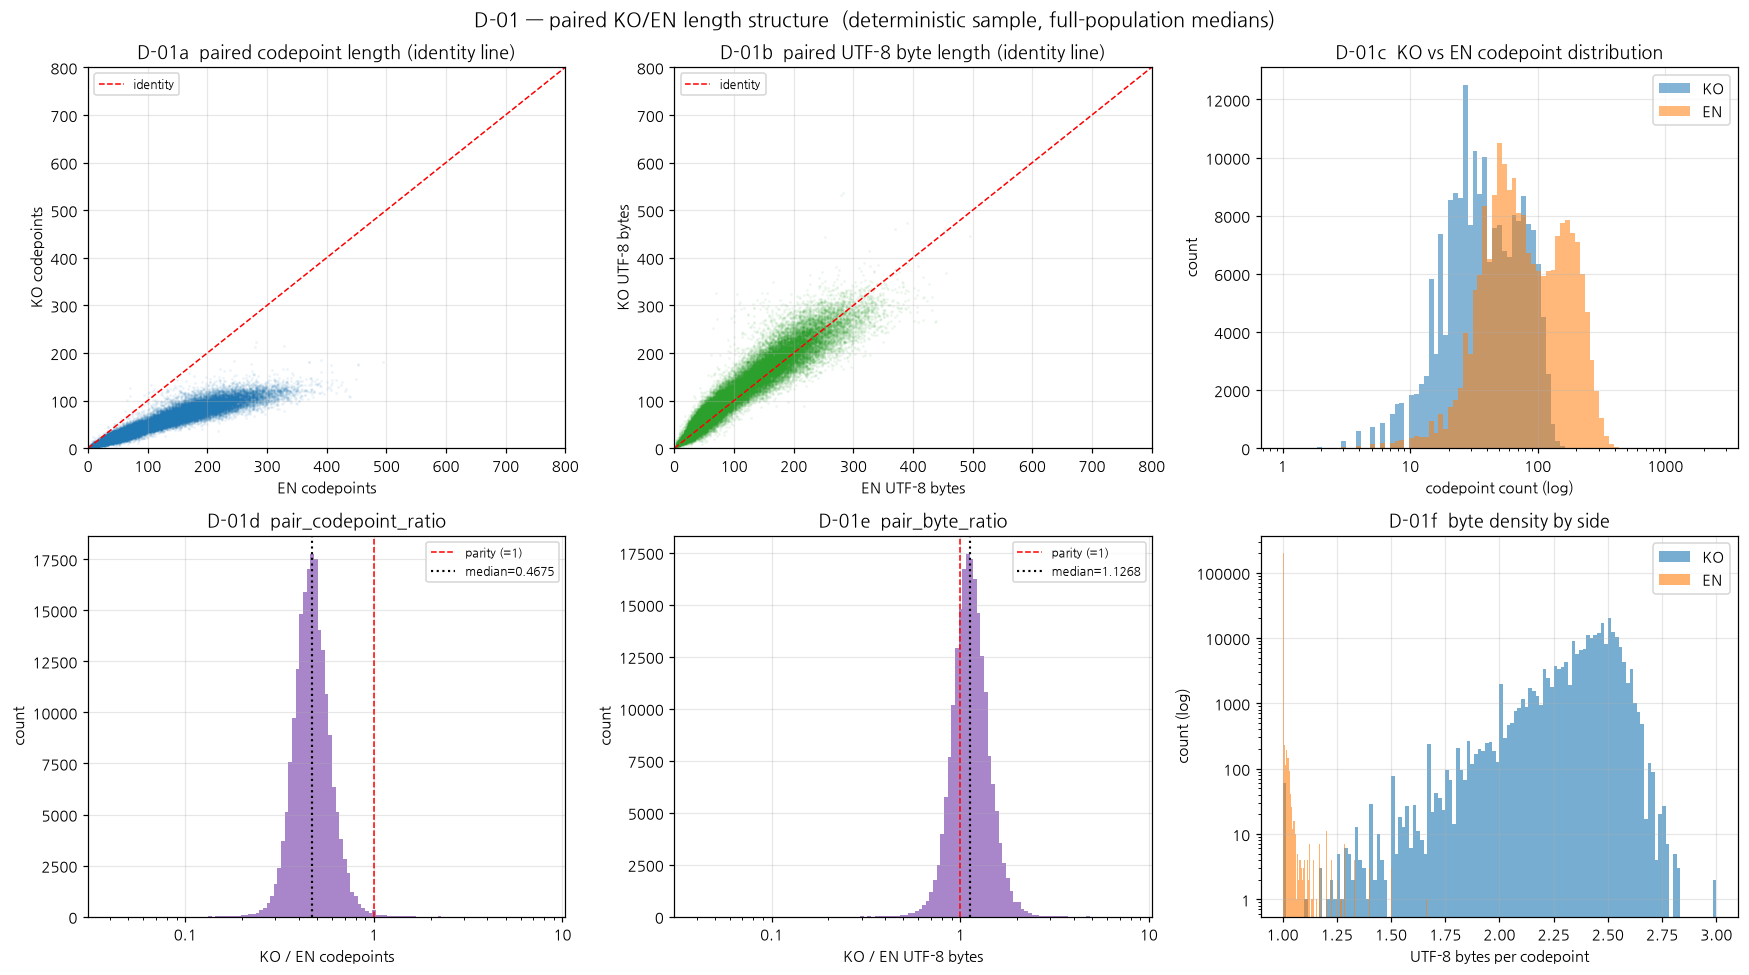

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9))

s = SAMPLE.sample(60_000, random_state=20260816)
ax[0, 0].scatter(s["en_codepoint_count"], s["ko_codepoint_count"], s=1, alpha=0.05, rasterized=True)
lim = 800
ax[0, 0].plot([0, lim], [0, lim], "r--", lw=1, label="identity")
ax[0, 0].set(xlim=(0, lim), ylim=(0, lim), xlabel="EN codepoints", ylabel="KO codepoints",
             title="D-01a  paired codepoint length (identity line)")
ax[0, 0].legend(loc="upper left", fontsize=8)

ax[0, 1].scatter(s["en_utf8_bytes"], s["ko_utf8_bytes"], s=1, alpha=0.05, rasterized=True, color="tab:green")
ax[0, 1].plot([0, lim], [0, lim], "r--", lw=1, label="identity")
ax[0, 1].set(xlim=(0, lim), ylim=(0, lim), xlabel="EN UTF-8 bytes", ylabel="KO UTF-8 bytes",
             title="D-01b  paired UTF-8 byte length (identity line)")
ax[0, 1].legend(loc="upper left", fontsize=8)

for col, lbl, c in [("ko_codepoint_count", "KO", "tab:blue"), ("en_codepoint_count", "EN", "tab:orange")]:
    ax[0, 2].hist(SAMPLE[col], bins=np.logspace(0, 3.4, 90), alpha=0.55, label=lbl, color=c)
ax[0, 2].set(xscale="log", xlabel="codepoint count (log)", ylabel="count",
             title="D-01c  KO vs EN codepoint distribution")
ax[0, 2].legend()

for col, ttl, xl in [("pair_codepoint_ratio", "D-01d  pair_codepoint_ratio", "KO / EN codepoints"),
                     ("pair_byte_ratio", "D-01e  pair_byte_ratio", "KO / EN UTF-8 bytes")]:
    a = ax[1, 0] if col == "pair_codepoint_ratio" else ax[1, 1]
    a.hist(SAMPLE[col], bins=np.logspace(-1.4, 0.9, 120), color="tab:purple", alpha=0.8)
    a.axvline(1.0, color="r", ls="--", lw=1, label="parity (=1)")
    a.axvline(dist.loc[col, "median"], color="k", ls=":", lw=1.4,
              label=f"median={dist.loc[col,'median']:.4f}")
    a.set(xscale="log", xlabel=xl, ylabel="count", title=ttl)
    a.legend(fontsize=8)

for col, lbl, c in [("ko_bytes_per_codepoint", "KO", "tab:blue"),
                    ("en_bytes_per_codepoint", "EN", "tab:orange")]:
    ax[1, 2].hist(SAMPLE[col], bins=120, alpha=0.6, label=lbl, color=c)
ax[1, 2].set(yscale="log", xlabel="UTF-8 bytes per codepoint", ylabel="count (log)",
             title="D-01f  byte density by side")
ax[1, 2].legend()

fig.suptitle("D-01 — paired KO/EN length structure  (deterministic sample, full-population medians)",
             fontsize=13)
ascii_log_ticks(fig)
fig.tight_layout()
plt.show()

### Panel D-02 — heavy tails and boundary behaviour

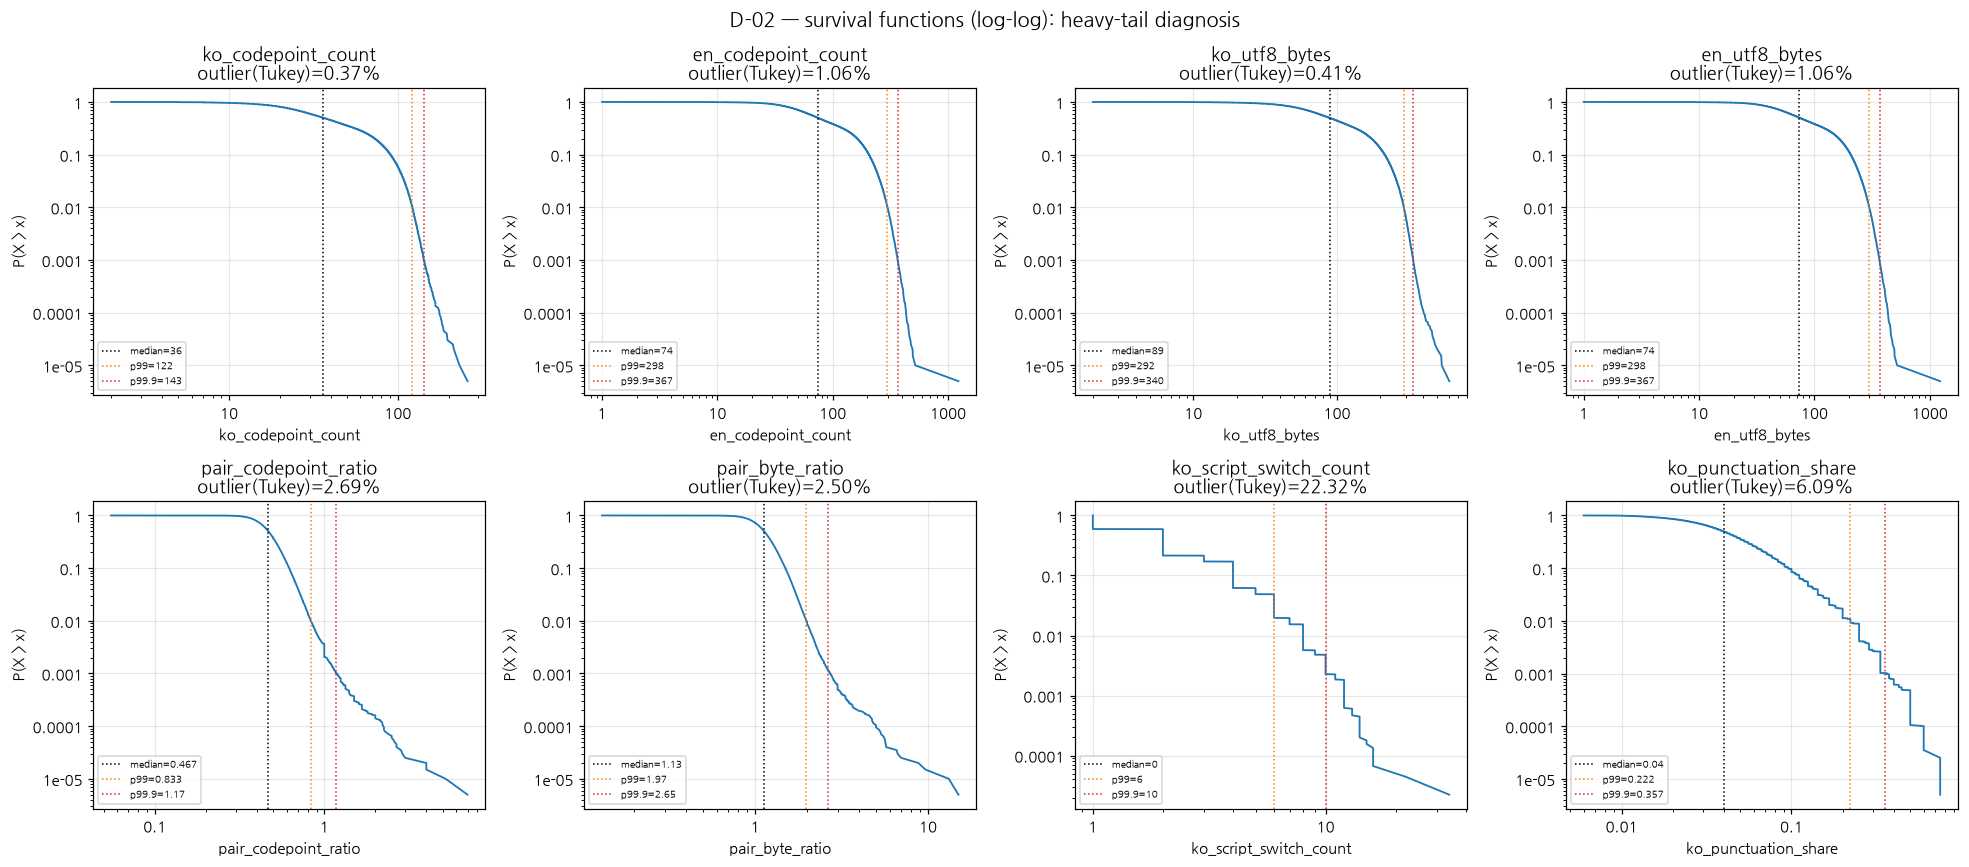

In [11]:
TAIL = ["ko_codepoint_count", "en_codepoint_count", "ko_utf8_bytes", "en_utf8_bytes",
        "pair_codepoint_ratio", "pair_byte_ratio", "ko_script_switch_count", "ko_punctuation_share"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for a, f in zip(axes.ravel(), TAIL):
    v = SAMPLE[f].to_numpy(dtype=float)
    v = np.sort(v[v > 0]) if f != "pair_codepoint_diff" else np.sort(v)
    surv = 1.0 - np.arange(len(v)) / len(v)
    a.plot(v, surv, lw=1.2)
    for q, c in [("median", "k"), ("p99", "tab:orange"), ("p99.9", "tab:red")]:
        a.axvline(dist.loc[f, q], color=c, ls=":", lw=1, label=f"{q}={dist.loc[f,q]:.3g}")
    a.set(xscale="log", yscale="log", xlabel=f, ylabel="P(X > x)",
          title=f"{f}\noutlier(Tukey)={100*dist.loc[f,'tukey_outlier_rate']:.2f}%")
    a.legend(fontsize=6.5, loc="lower left")
fig.suptitle("D-02 — survival functions (log-log): heavy-tail diagnosis", fontsize=13)
ascii_log_ticks(fig)
fig.tight_layout()
plt.show()

## 5 — Boundary and extreme regions

The pair ratios are the features the downstream decomposition depends on
(`logTP = logCodePointRatio + logByteDensityRatio + logCompressionPenalty`, SSOT §8), so their
extremes are characterised explicitly. Only **aggregate** structure is reported — no raw text.

In [12]:
BOUNDARY_SQL = (
    "SELECT"
    "  SUM((pair_codepoint_ratio >= 2)::INT)    AS pcr_ge_2,"
    "  SUM((pair_codepoint_ratio >= 5)::INT)    AS pcr_ge_5,"
    "  SUM((pair_codepoint_ratio >= 10)::INT)   AS pcr_ge_10,"
    "  SUM((pair_codepoint_ratio < 0.10)::INT)  AS pcr_lt_0_10,"
    "  SUM((pair_codepoint_ratio < 0.05)::INT)  AS pcr_lt_0_05,"
    "  SUM((ko_codepoint_count <= 3)::INT)      AS ko_len_le_3,"
    "  SUM((en_codepoint_count <= 3)::INT)      AS en_len_le_3,"
    "  SUM((ko_hangul_share = 0)::INT)          AS ko_zero_hangul,"
    "  SUM((en_hangul_share > 0)::INT)          AS en_has_hangul,"
    "  SUM((ko_bytes_per_codepoint = 3.0)::INT) AS ko_pure_3byte"
    f" FROM {REP}")
bnd = con.execute(BOUNDARY_SQL).fetchdf().iloc[0]
print(f"{'boundary condition':22s} {'N':>10s} {'share':>10s}")
for k in bnd.index:
    print(f"{k:22s} {int(bnd[k]):>10,} {100*int(bnd[k])/EXPECTED_N:9.4f}%")

print("\nstructure of the pair_codepoint_ratio tails vs the body (means, aggregate only):")
TAILS_SQL = (
    "SELECT grp, COUNT(*) AS n,"
    "  AVG(ko_codepoint_count) AS ko_cp, AVG(en_codepoint_count) AS en_cp,"
    "  AVG(ko_hangul_share) AS ko_hangul, AVG(ko_digit_share) AS ko_digit,"
    "  AVG(ko_punctuation_share) AS ko_punct, AVG(ko_latin_share) AS ko_latin,"
    "  AVG(pair_byte_ratio) AS pair_byte_ratio"
    " FROM (SELECT *, CASE WHEN pair_codepoint_ratio >= 2 THEN 'tail_ge_2'"
    "                      WHEN pair_codepoint_ratio < 0.10 THEN 'tail_lt_0.10'"
    f"                      ELSE 'body' END AS grp FROM {REP})"
    " GROUP BY grp ORDER BY n DESC")
tails = con.execute(TAILS_SQL).fetchdf()
tails.round(4)

boundary condition              N      share
pcr_ge_2                      458    0.0119%
pcr_ge_5                       21    0.0005%
pcr_ge_10                       2    0.0001%
pcr_lt_0_10                    54    0.0014%
pcr_lt_0_05                     4    0.0001%
ko_len_le_3                 5,013    0.1307%
en_len_le_3                   696    0.0181%
ko_zero_hangul              1,285    0.0335%
en_has_hangul                 358    0.0093%
ko_pure_3byte                  34    0.0009%

structure of the pair_codepoint_ratio tails vs the body (means, aggregate only):


,grp,n,ko_cp,en_cp,ko_hangul,ko_digit,ko_punct,ko_latin,pair_byte_ratio
0,body,3835476,45.7010,100.3175,0.7061,0.0149,0.0509,0.0134,1.1611
1,tail_ge_2,458,19.9607,7.8734,0.6004,0.0147,0.1667,0.0138,6.1013
2,tail_lt_0.10,54,8.9630,158.5185,0.6917,0.0012,0.2382,0.0000,0.1891


Both tails are minute (458 + 54 rows = 0.013% of the cohort) and each is structurally coherent
rather than corrupt:

- **`pair_codepoint_ratio ≥ 2`** — short KO (mean ≈ 20 cp) against *even shorter* EN (mean ≈ 8 cp),
  punctuation-rich (0.167 vs 0.051 in the body). This is consistent with an EN-side abbreviation,
  acronym, or symbol answer against a spelled-out Korean phrase; the aggregate profile does not
  by itself identify which of those it is.
- **`pair_codepoint_ratio < 0.10`** — very short KO (mean ≈ 9 cp) against long EN (mean ≈ 159 cp),
  again punctuation-heavy. Consistent with heavily condensed Korean rendering of a long English
  sentence.

Per SSOT §16.3, extremes are **not** deleted here; they are classified. The canonical per-case
extreme audit panel (with token IDs, regex chunks, and morphology) is NB07 work and is not attempted.

## 6 — Marginal strata

Per-stratum `N`, median, IQR, p05/p95/p99 and outlier prevalence. **No formal hypothesis test is
performed** — this is descriptive heterogeneity only.

In [13]:
STRATUM_COLS = ["logical_corpus", "translation_direction", "domain", "length_stratum", "sentence_type"]
TARGETS = ["pair_codepoint_ratio", "pair_byte_ratio", "ko_codepoint_count", "en_codepoint_count",
           "ko_bytes_per_codepoint", "ko_script_switch_count"]
FENCE = {f: float(dist.loc[f, "tukey_upper"]) for f in TARGETS}

strata_tables = {}
for st in STRATUM_COLS:
    sel = [f"{st} AS level", "COUNT(*) AS n"]
    for f in TARGETS:
        sel += [f'quantile_cont({f}, [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]) AS "{f}__q"',
                f'SUM(({f} > {FENCE[f]:.17g})::INT) AS "{f}__outl"']
    df = con.execute(f"SELECT {', '.join(sel)} FROM j GROUP BY {st} ORDER BY n DESC").fetchdf()
    rows = []
    for _, r in df.iterrows():
        rec = {"level": str(r["level"]), "n": int(r["n"])}
        for f in TARGETS:
            q = list(r[f"{f}__q"])
            rec[f"{f}__p05"], rec[f"{f}__p25"], rec[f"{f}__median"] = q[0], q[1], q[2]
            rec[f"{f}__p75"], rec[f"{f}__p95"], rec[f"{f}__p99"] = q[3], q[4], q[5]
            rec[f"{f}__iqr"] = q[3] - q[1]
            rec[f"{f}__outlier_rate"] = int(r[f"{f}__outl"]) / int(r["n"])
        rows.append(rec)
    table = pd.DataFrame(rows)
    if st == "length_stratum":            # 자연 순서 Q1..Q5로 정렬해야 길이 gradient가 보인다
        table = table.sort_values("level").reset_index(drop=True)
    strata_tables[st] = table

DEGENERATE = [st for st, t in strata_tables.items() if len(t) < 2]
print(f"degenerate strata (single level -> not informative): {DEGENERATE}\n")

for st in STRATUM_COLS:
    t = strata_tables[st]
    print(f"=== {st} ===")
    show = t[["level", "n"] + [f"pair_codepoint_ratio__{k}" for k in ("p05", "median", "p95", "p99", "iqr", "outlier_rate")]
             + [f"pair_byte_ratio__{k}" for k in ("median", "p99", "outlier_rate")]
             + ["ko_codepoint_count__median", "en_codepoint_count__median"]]
    print(show.round(4).to_string(index=False))
    print()

degenerate strata (single level -> not informative): ['sentence_type']

=== logical_corpus ===
level       n  pair_codepoint_ratio__p05  pair_codepoint_ratio__median  pair_codepoint_ratio__p95  pair_codepoint_ratio__p99  pair_codepoint_ratio__iqr  pair_codepoint_ratio__outlier_rate  pair_byte_ratio__median  pair_byte_ratio__p99  pair_byte_ratio__outlier_rate  ko_codepoint_count__median  en_codepoint_count__median
  025 2485963                     0.3333                        0.4878                     0.7097                     0.8667                     0.1419                              0.0377                   1.1875                2.0400                         0.0357                        26.0                        53.0
  026 1350025                     0.3358                        0.4387                     0.5902                     0.7037                     0.0992                              0.0071                   1.0471                1.6301                         0.

### Panel D-03 — heterogeneity across strata

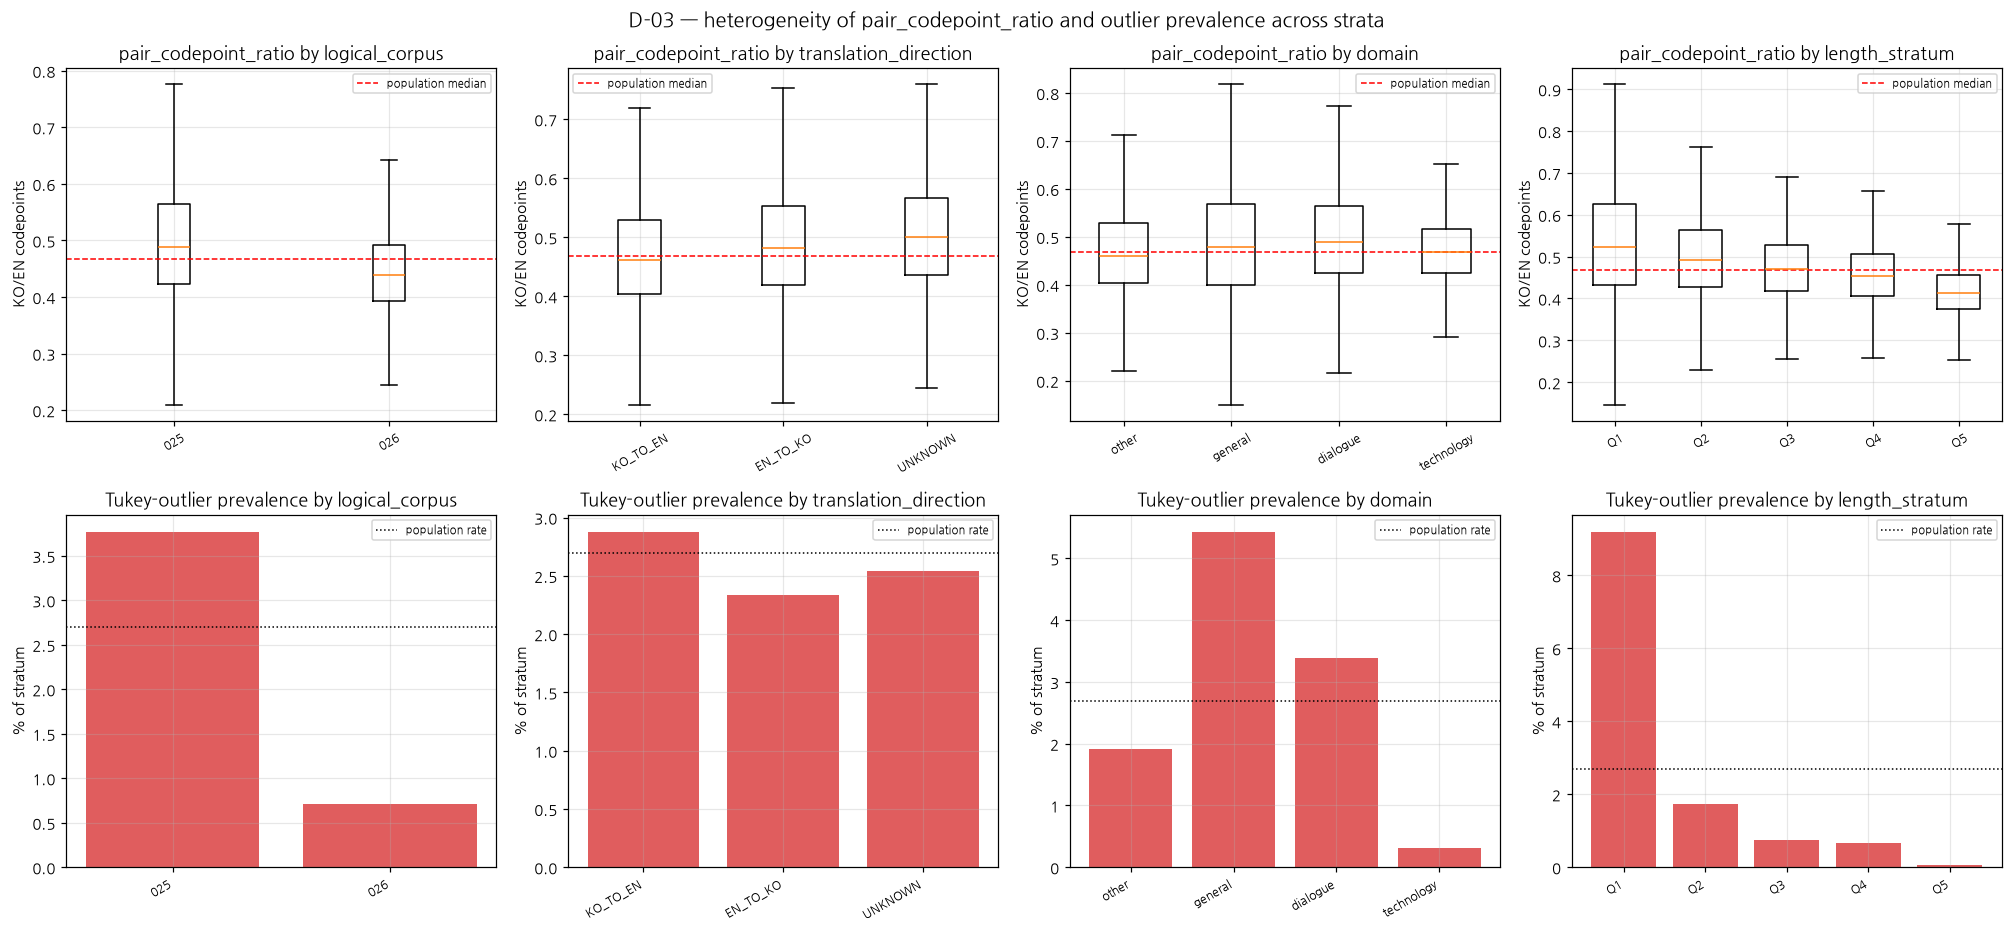

In [14]:
PLOT_STRATA = [st for st in STRATUM_COLS if st not in DEGENERATE]
fig, axes = plt.subplots(2, len(PLOT_STRATA), figsize=(4.6 * len(PLOT_STRATA), 8.6))
for c, st in enumerate(PLOT_STRATA):
    order = list(strata_tables[st]["level"] if st == "length_stratum"
                 else strata_tables[st].sort_values("n", ascending=False)["level"])
    data = [SAMPLE.loc[SAMPLE[st] == lv, "pair_codepoint_ratio"].to_numpy() for lv in order]
    axes[0, c].boxplot(data, tick_labels=order, showfliers=False)
    axes[0, c].axhline(dist.loc["pair_codepoint_ratio", "median"], color="r", ls="--", lw=1,
                       label="population median")
    axes[0, c].set(title=f"pair_codepoint_ratio by {st}", ylabel="KO/EN codepoints")
    axes[0, c].tick_params(axis="x", rotation=30, labelsize=8)
    axes[0, c].legend(fontsize=7)

    t = strata_tables[st].set_index("level").loc[order]
    axes[1, c].bar(range(len(order)), 100 * t["pair_codepoint_ratio__outlier_rate"],
                   color="tab:red", alpha=0.75)
    axes[1, c].set_xticks(range(len(order)))
    axes[1, c].set_xticklabels(order, rotation=30, ha="right", fontsize=8)
    axes[1, c].axhline(100 * dist.loc["pair_codepoint_ratio", "tukey_outlier_rate"],
                       color="k", ls=":", lw=1, label="population rate")
    axes[1, c].set(title=f"Tukey-outlier prevalence by {st}", ylabel="% of stratum")
    axes[1, c].legend(fontsize=7)
fig.suptitle("D-03 — heterogeneity of pair_codepoint_ratio and outlier prevalence across strata",
             fontsize=13)
ascii_log_ticks(fig)
fig.tight_layout()
plt.show()

## 7 — Script and surface structure (KO side centred)

In [15]:
SURFACE_SQL = (
    "SELECT COUNT(*) AS n,"
    "  AVG((ko_latin_share  > 0.20)::INT)      AS ko_english_heavy,"
    "  AVG((ko_digit_share  > 0.20)::INT)      AS ko_digit_heavy,"
    "  AVG((ko_punctuation_share > 0.20)::INT) AS ko_punct_heavy,"
    "  AVG((ko_hangul_share < 0.50)::INT)      AS ko_low_hangul,"
    "  AVG((ko_script_type_count >= 2)::INT)   AS ko_mixed_script,"
    "  AVG((ko_script_type_count  = 3)::INT)   AS ko_tri_script,"
    "  AVG((ko_script_switch_count >= 6)::INT) AS ko_high_switch,"
    "  AVG((en_hangul_share > 0)::INT)         AS en_contains_hangul"
    f" FROM {REP}")
surface = con.execute(SURFACE_SQL).fetchdf().iloc[0]
print("KO-side surface prevalence (full population):")
for k in surface.index[1:]:
    print(f"  {k:22s} {100*float(surface[k]):8.4f}%   N={int(round(float(surface[k])*EXPECTED_N)):>9,}")

FLAGS_SQL = (
    "SELECT"
    "  AVG(ko_url_flag::INT) AS ko_url,     AVG(en_url_flag::INT) AS en_url,"
    "  AVG(ko_email_flag::INT) AS ko_email, AVG(en_email_flag::INT) AS en_email,"
    "  AVG(ko_emoji_flag::INT) AS ko_emoji, AVG(en_emoji_flag::INT) AS en_emoji,"
    "  AVG(ko_code_like_flag::INT) AS ko_code_like,"
    "  AVG(en_code_like_flag::INT) AS en_code_like,"
    "  AVG((ko_url_flag AND en_url_flag)::INT)             AS both_url,"
    "  AVG((ko_emoji_flag AND en_emoji_flag)::INT)         AS both_emoji,"
    "  AVG((ko_code_like_flag AND en_code_like_flag)::INT) AS both_code_like,"
    "  AVG((ko_url_flag OR ko_email_flag OR ko_emoji_flag OR ko_code_like_flag"
    "    OR en_url_flag OR en_email_flag OR en_emoji_flag OR en_code_like_flag)::INT) AS any_flag"
    f" FROM {REP}")
flags = con.execute(FLAGS_SQL).fetchdf().iloc[0]
print("\nspecial-expression flag prevalence and overlap (full population):")
for k in flags.index:
    print(f"  {k:16s} {100*float(flags[k]):8.4f}%   N={int(round(float(flags[k])*EXPECTED_N)):>9,}")

KO-side surface prevalence (full population):
  ko_english_heavy         1.0047%   N=   38,539
  ko_digit_heavy           0.4517%   N=   17,329
  ko_punct_heavy           1.0937%   N=   41,953
  ko_low_hangul            1.5426%   N=   59,173
  ko_mixed_script         22.3169%   N=  856,075
  ko_tri_script            0.4905%   N=   18,814
  ko_high_switch           1.1212%   N=   43,009
  en_contains_hangul       0.0093%   N=      358

special-expression flag prevalence and overlap (full population):
  ko_url             0.0020%   N=       75
  en_url             0.0019%   N=       73
  ko_email           0.0088%   N=      337
  en_email           0.0088%   N=      337
  ko_emoji           0.0011%   N=       43
  en_emoji           0.0011%   N=       42
  ko_code_like       8.0434%   N=  308,544
  en_code_like       2.3480%   N=   90,069
  both_url           0.0019%   N=       72
  both_emoji         0.0010%   N=       39
  both_code_like     0.2947%   N=   11,304
  any_flag          10

In [16]:
def surface_by(stratum: str) -> pd.DataFrame:
    'stratum 수준별 KO surface-structure / flag prevalence를 % 단위로 반환한다.'
    sql = (
        f"SELECT {stratum} AS level, COUNT(*) AS n,"
        "  AVG((ko_latin_share > 0.20)::INT)       AS eng_heavy,"
        "  AVG((ko_digit_share > 0.20)::INT)       AS digit_heavy,"
        "  AVG((ko_punctuation_share > 0.20)::INT) AS punct_heavy,"
        "  AVG((ko_script_type_count >= 2)::INT)   AS mixed_script,"
        "  AVG((ko_url_flag OR en_url_flag)::INT)  AS url,"
        "  AVG((ko_code_like_flag OR en_code_like_flag)::INT) AS code_like,"
        "  AVG((ko_emoji_flag OR en_emoji_flag)::INT) AS emoji"
        f" FROM j GROUP BY {stratum} ORDER BY n DESC")
    return con.execute(sql).fetchdf()


surface_by_stratum = {}
print("prevalence by stratum:\n")
for st in ["logical_corpus", "translation_direction", "domain"]:
    df = surface_by(st)
    surface_by_stratum[st] = df.copy()
    for c in df.columns[2:]:
        df[c] = (100 * df[c]).round(3)
    print(f"=== {st} ===  (values are % of the stratum)")
    print(df.to_string(index=False))
    print()

# carried into the §10 summary so the narrative quotes a computed value, never a literal
CODE_LIKE_TECH_RATE = float(
    surface_by_stratum["domain"].set_index("level").loc["technology", "code_like"])
CODE_LIKE_026_RATE = float(
    surface_by_stratum["logical_corpus"].set_index("level").loc["026", "code_like"])
print(f"code_like prevalence: domain=technology {100*CODE_LIKE_TECH_RATE:.2f}%   "
      f"corpus=026 {100*CODE_LIKE_026_RATE:.2f}%")

prevalence by stratum:



=== logical_corpus ===  (values are % of the stratum)
level       n  eng_heavy  digit_heavy  punct_heavy  mixed_script   url  code_like  emoji
  025 2485963      0.987        0.551        1.673        18.586 0.002      2.324  0.001
  026 1350025      1.037        0.269        0.027        29.188 0.001     24.410  0.001



=== translation_direction ===  (values are % of the stratum)
   level       n  eng_heavy  digit_heavy  punct_heavy  mixed_script   url  code_like  emoji
KO_TO_EN 2512152      1.047        0.448        1.580        29.334 0.002     14.335  0.002
EN_TO_KO 1273289      0.939        0.465        0.175         9.075 0.001      2.076  0.000
 UNKNOWN   50547      0.568        0.319        0.073         7.126 0.000      1.504  0.000



=== domain ===  (values are % of the stratum)
     level       n  eng_heavy  digit_heavy  punct_heavy  mixed_script   url  code_like  emoji
     other 2155630      1.082        0.276        0.033        20.989 0.003      6.827  0.002
   general  804291      0.586        0.749        4.998        32.643 0.000      2.259  0.000
  dialogue  516162      1.241        0.617        0.194        10.174 0.002      2.173  0.000
technology  359905      1.136        0.605        0.013        24.608 0.001     58.557  0.000

code_like prevalence: domain=technology 58.56%   corpus=026 24.41%


### `code_like_flag` specificity — a label caveat, not a defect

`code_like_flag` reaches **58.6%** inside `domain = technology` and **24.4%** inside corpus `026`.
That is high enough to matter for interpretation, so the frozen pattern
(`representation.py:53–56`) is decomposed on a deterministic sample of flagged rows. Only aggregate
match counts are produced; no text is retained or exported.

In [17]:
import regex

ALTERNATIVES = {
    "brace_or_semicolon": r"[{};]",
    "arrow": r"=>",
    "keyword": r"\b(?:function|def|import|class|return|const|let|var)\b",
    "call_like_parenthetical": r"\w+\([^)]*\)",
}
patterns = {k: regex.compile(v, flags=regex.IGNORECASE) for k, v in ALTERNATIVES.items()}

FLAGGED_SQL = (
    "SELECT p.ko_text_analysis AS ko, p.en_text_analysis AS en,"
    "       r.ko_code_like_flag AS ko_flag, r.en_code_like_flag AS en_flag"
    f" FROM {REP} r JOIN read_parquet('{PAIR_PATH.as_posix()}') p USING (pair_id)"
    " WHERE r.ko_code_like_flag OR r.en_code_like_flag"
    f" ORDER BY md5(r.pair_id || '{SAMPLE_SALT}') LIMIT 50000")
flagged = con.execute(FLAGGED_SQL).fetchdf()

matches = {k: 0 for k in ALTERNATIVES}
sole_cause = {k: 0 for k in ALTERNATIVES}
inspected = 0
for _, row in flagged.iterrows():
    for text, flag in ((row["ko"], row["ko_flag"]), (row["en"], row["en_flag"])):
        if not flag:
            continue
        inspected += 1
        hits = [k for k, p in patterns.items() if p.search(text)]
        for k in hits:
            matches[k] += 1
        if len(hits) == 1:
            sole_cause[hits[0]] += 1
del flagged                                    # raw text is not retained beyond this cell

print(f"flagged text sides inspected: {inspected:,}  (deterministic sample, aggregate output only)\n")
print(f"{'pattern alternative':26s} {'matches':>10s} {'share':>9s} {'sole cause':>11s} {'share':>9s}")
for k in ALTERNATIVES:
    print(f"{k:26s} {matches[k]:>10,} {100*matches[k]/inspected:8.2f}% "
          f"{sole_cause[k]:>11,} {100*sole_cause[k]/inspected:8.2f}%")
CODE_LIKE_PARENTHETICAL_SHARE = sole_cause["call_like_parenthetical"] / inspected
CODE_LIKE_KEYWORD_SHARE = sole_cause["keyword"] / inspected

flagged text sides inspected: 51,421  (deterministic sample, aggregate output only)

pattern alternative           matches     share  sole cause     share
brace_or_semicolon                525     1.02%         493     0.96%
arrow                               0     0.00%           0     0.00%
keyword                        10,967    21.33%      10,922    21.24%
call_like_parenthetical        39,996    77.78%      39,939    77.67%


**Finding.** Roughly 78% of `code_like_flag` firings are caused *solely* by the
`\w+\([^)]*\)` alternative — i.e. an ordinary parenthetical gloss such as `용어(term)`, which is
pervasive in Korean technical and patent prose — and a further ~21% solely by the `keyword`
alternative, where the "keywords" (`class`, `return`, `import`, `let`, `var`, `const`, `def`)
are also ordinary English words. Genuine code punctuation (`{`, `}`, `;`, `=>`) accounts for ~1%.

The feature is computed **exactly** as its frozen definition specifies, so this is not an
implementation defect and requires no change. It is a **naming/semantic caveat**: in this corpus
`code_like_flag` behaves as a *parenthetical-and-Latin-keyword surface flag*, not as a code detector,
and must not be interpreted as "this pair contains source code" in any downstream model or narrative.

## 8 — Correlation and redundancy

- **Pearson**: computed over the **full population** as a DuckDB aggregate (single scan), not sampled.
- **Spearman**: rank correlation on the deterministic bounded sample (n = 200,000).

> This section is a redundancy *diagnosis*. It is **not** a G5 collinearity gate result, and no
> feature is dropped here. VIF, condition number and the identifiability audit are G5 work.

In [18]:
t0 = time.time()
sel = ", ".join(f'corr({NUMERIC[i]}, {NUMERIC[j]}) AS "c_{i}_{j}"'
                for i in range(len(NUMERIC)) for j in range(i + 1, len(NUMERIC)))
d = con.execute(f"SELECT {sel} FROM {REP}").fetchdf().iloc[0]
P = np.eye(len(NUMERIC))
for i in range(len(NUMERIC)):
    for j in range(i + 1, len(NUMERIC)):
        v = float(d[f"c_{i}_{j}"]) if d[f"c_{i}_{j}"] == d[f"c_{i}_{j}"] else np.nan
        P[i, j] = P[j, i] = v
print(f"Pearson (full population, {EXPECTED_N:,} rows) {P.shape} in {time.time()-t0:.1f}s")

from scipy.stats import rankdata
R = np.column_stack([rankdata(SAMPLE[c].to_numpy(dtype=float)) for c in NUMERIC])
S_rho = np.corrcoef(R, rowvar=False)
print(f"Spearman (deterministic sample n={len(SAMPLE):,}) {S_rho.shape}")

RHO_THRESHOLD = 0.90
idx = {f: i for i, f in enumerate(NUMERIC)}
redundant = []
for i in range(len(NUMERIC)):
    for j in range(i + 1, len(NUMERIC)):
        pe, sp = P[i, j], S_rho[i, j]
        if (pe == pe and abs(pe) >= RHO_THRESHOLD) or abs(sp) >= RHO_THRESHOLD:
            redundant.append({"feature_a": NUMERIC[i], "feature_b": NUMERIC[j],
                              "pearson_full": round(float(pe), 6),
                              "spearman_sample": round(float(sp), 6),
                              "max_abs": round(max(abs(pe), abs(sp)), 6)})
redundant = pd.DataFrame(redundant).sort_values("max_abs", ascending=False).reset_index(drop=True)
print(f"\npairs with |rho| >= {RHO_THRESHOLD}: {len(redundant)}")
redundant

Pearson (full population, 3,835,988 rows) (34, 34) in 1.8s


Spearman (deterministic sample n=200,000) (34, 34)

pairs with |rho| >= 0.9: 62


,feature_a,feature_b,pearson_full,spearman_sample,max_abs
0,ko_codepoint_count,ko_grapheme_count,1.000000,1.000000,1.000000
1,ko_whitespace_count,ko_space_run_count,1.000000,1.000000,1.000000
2,ko_bytes_per_codepoint,ko_bytes_per_grapheme,1.000000,1.000000,1.000000
3,en_whitespace_count,en_space_run_count,1.000000,1.000000,1.000000
4,pair_codepoint_ratio,pair_grapheme_ratio,1.000000,1.000000,1.000000
...,...,...,...,...,...
57,ko_whitespace_count,en_space_run_count,0.929916,0.933027,0.933027
58,ko_space_run_count,en_whitespace_count,0.929916,0.933027,0.933027
59,ko_whitespace_count,en_whitespace_count,0.929916,0.933027,0.933027
60,ko_space_run_count,en_space_run_count,0.929916,0.933027,0.933027


In [19]:
NAMED = [("ko_codepoint_count", "ko_grapheme_count"), ("ko_codepoint_count", "ko_utf8_bytes"),
         ("ko_utf8_bytes", "ko_grapheme_count"), ("en_codepoint_count", "en_grapheme_count"),
         ("en_codepoint_count", "en_utf8_bytes"), ("en_utf8_bytes", "en_grapheme_count"),
         ("ko_codepoint_count", "ko_whitespace_count"), ("en_codepoint_count", "en_whitespace_count"),
         ("ko_script_type_count", "ko_script_switch_count"),
         ("en_script_type_count", "en_script_switch_count"),
         ("ko_hangul_share", "ko_latin_share"), ("ko_hangul_share", "ko_bytes_per_codepoint"),
         ("pair_codepoint_ratio", "pair_grapheme_ratio"), ("pair_codepoint_ratio", "pair_byte_ratio"),
         ("pair_byte_ratio", "pair_codepoint_diff"), ("pair_codepoint_ratio", "pair_codepoint_diff")]
named = pd.DataFrame([{"feature_a": a, "feature_b": b,
                       "pearson_full": round(float(P[idx[a], idx[b]]), 6),
                       "spearman_sample": round(float(S_rho[idx[a], idx[b]]), 6)} for a, b in NAMED])
print("relationships named in the diagnostic brief:")
named

relationships named in the diagnostic brief:


,feature_a,feature_b,pearson_full,spearman_sample
0,ko_codepoint_count,ko_grapheme_count,1.000000,1.000000
1,ko_codepoint_count,ko_utf8_bytes,0.994355,0.996814
2,ko_utf8_bytes,ko_grapheme_count,0.994354,0.996814
3,en_codepoint_count,en_grapheme_count,1.000000,1.000000
4,en_codepoint_count,en_utf8_bytes,0.999989,0.999997
5,en_utf8_bytes,en_grapheme_count,0.999989,0.999997
6,ko_codepoint_count,ko_whitespace_count,0.978135,0.982972
7,en_codepoint_count,en_whitespace_count,0.981776,0.981372
8,ko_script_type_count,ko_script_switch_count,0.788798,0.990906
9,en_script_type_count,en_script_switch_count,0.874738,0.999304


In [20]:
# exact-equality audit: how much of the high correlation is literal duplication?
EQ = [("ko_grapheme_count", "ko_codepoint_count"), ("en_grapheme_count", "en_codepoint_count"),
      ("pair_grapheme_ratio", "pair_codepoint_ratio"),
      ("ko_space_run_count", "ko_whitespace_count"), ("en_space_run_count", "en_whitespace_count"),
      ("ko_bytes_per_grapheme", "ko_bytes_per_codepoint"),
      ("en_bytes_per_grapheme", "en_bytes_per_codepoint"),
      ("en_utf8_bytes", "en_codepoint_count")]
sel = ", ".join(f'SUM(({a} <> {b})::INT) AS "{a}__vs__{b}"' for a, b in EQ)
eq = con.execute(f"SELECT {sel} FROM {REP}").fetchdf().iloc[0]
print(f"{'feature pair':56s} {'rows differing':>15s} {'share':>10s}")
exact_dup = []
for a, b in EQ:
    nd = int(eq[f"{a}__vs__{b}"])
    print(f"{a + '  vs  ' + b:56s} {nd:>15,} {100*nd/EXPECTED_N:9.5f}%")
    exact_dup.append({"feature_a": a, "feature_b": b, "rows_differing": nd,
                      "differing_rate": nd / EXPECTED_N})
exact_dup = pd.DataFrame(exact_dup)

feature pair                                              rows differing      share
ko_grapheme_count  vs  ko_codepoint_count                             29   0.00076%
en_grapheme_count  vs  en_codepoint_count                             17   0.00044%
pair_grapheme_ratio  vs  pair_codepoint_ratio                         43   0.00112%
ko_space_run_count  vs  ko_whitespace_count                           26   0.00068%
en_space_run_count  vs  en_whitespace_count                           26   0.00068%
ko_bytes_per_grapheme  vs  ko_bytes_per_codepoint                     29   0.00076%
en_bytes_per_grapheme  vs  en_bytes_per_codepoint                     17   0.00044%
en_utf8_bytes  vs  en_codepoint_count                             21,885   0.57052%


### Panel D-04 — correlation structure

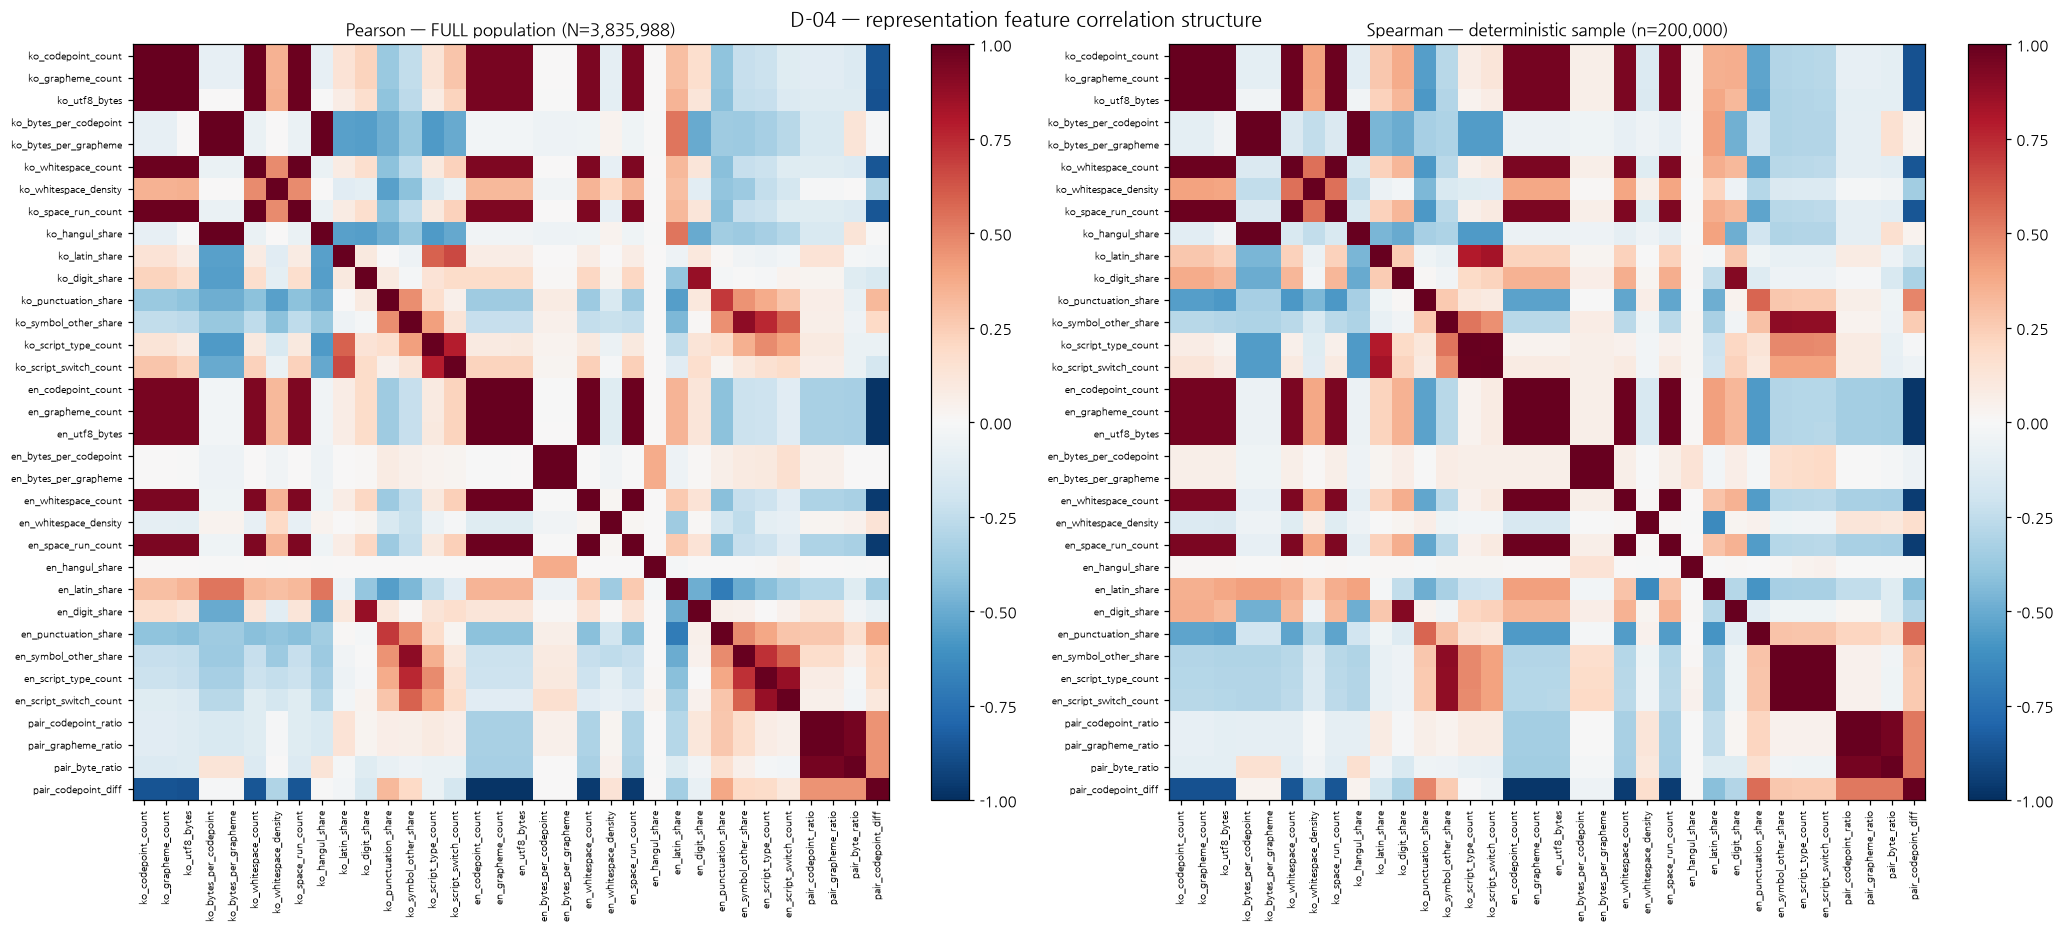

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(19, 8.4))
for a, M, ttl in [(ax[0], P, f"Pearson — FULL population (N={EXPECTED_N:,})"),
                  (ax[1], S_rho, f"Spearman — deterministic sample (n={len(SAMPLE):,})")]:
    im = a.imshow(M, vmin=-1, vmax=1, cmap="RdBu_r")
    a.set_xticks(range(len(NUMERIC)))
    a.set_yticks(range(len(NUMERIC)))
    a.set_xticklabels(NUMERIC, rotation=90, fontsize=6.5)
    a.set_yticklabels(NUMERIC, fontsize=6.5)
    a.set_title(ttl, fontsize=11)
    a.grid(False)
    fig.colorbar(im, ax=a, fraction=0.046)
fig.suptitle("D-04 — representation feature correlation structure", fontsize=13)
ascii_log_ticks(fig)
fig.tight_layout()
plt.show()

## 9 — Exploratory PCA

Standardised PCA on a deterministic sample of ≤ 100,000 rows, purely to identify what the dominant
axes of variation are. No UMAP / t-SNE and no new dependency is installed.

In [22]:
X = SAMPLE.iloc[:PCA_N][NUMERIC].to_numpy(dtype=float)
sd = X.std(axis=0)
X = (X - X.mean(axis=0)) / np.where(sd == 0, 1.0, sd)
_, sv, Vt = np.linalg.svd(X, full_matrices=False)
evr = (sv ** 2 / (len(X) - 1)) / ((sv ** 2 / (len(X) - 1)).sum())

print(f"standardized PCA  n={len(X):,}  p={len(NUMERIC)}")
print("explained variance ratio: " + "  ".join(f"PC{k+1}={evr[k]:.3f}" for k in range(6)))
print(f"cumulative: PC1-3={evr[:3].sum():.3f}   PC1-6={evr[:6].sum():.3f}")
pca_loadings = []
for k in range(3):
    order = np.argsort(-np.abs(Vt[k]))[:8]
    pca_loadings.append({"pc": k + 1, "evr": float(evr[k]),
                         "top_loadings": [{"feature": NUMERIC[m], "loading": round(float(Vt[k][m]), 4)}
                                          for m in order]})
    print(f"\nPC{k+1} ({100*evr[k]:.1f}%): " +
          ",  ".join(f"{NUMERIC[m]}={Vt[k][m]:+.3f}" for m in order))

standardized PCA  n=100,000  p=34
explained variance ratio: PC1=0.351  PC2=0.190  PC3=0.091  PC4=0.074  PC5=0.059  PC6=0.055
cumulative: PC1-3=0.632   PC1-6=0.820

PC1 (35.1%): en_codepoint_count=-0.282,  en_grapheme_count=-0.282,  en_utf8_bytes=-0.282,  en_space_run_count=-0.279,  en_whitespace_count=-0.279,  ko_utf8_bytes=-0.276,  ko_codepoint_count=-0.274,  ko_grapheme_count=-0.274

PC2 (19.0%): ko_hangul_share=-0.357,  ko_bytes_per_grapheme=-0.356,  ko_bytes_per_codepoint=-0.356,  ko_script_type_count=+0.281,  en_latin_share=-0.241,  ko_script_switch_count=+0.235,  en_symbol_other_share=+0.222,  ko_symbol_other_share=+0.222

PC3 (9.1%): pair_codepoint_ratio=-0.469,  pair_grapheme_ratio=-0.469,  pair_byte_ratio=-0.455,  ko_symbol_other_share=+0.232,  en_script_type_count=+0.214,  en_script_switch_count=+0.189,  en_symbol_other_share=+0.165,  ko_whitespace_density=-0.153


### Panel D-05 — principal axes of representation variation

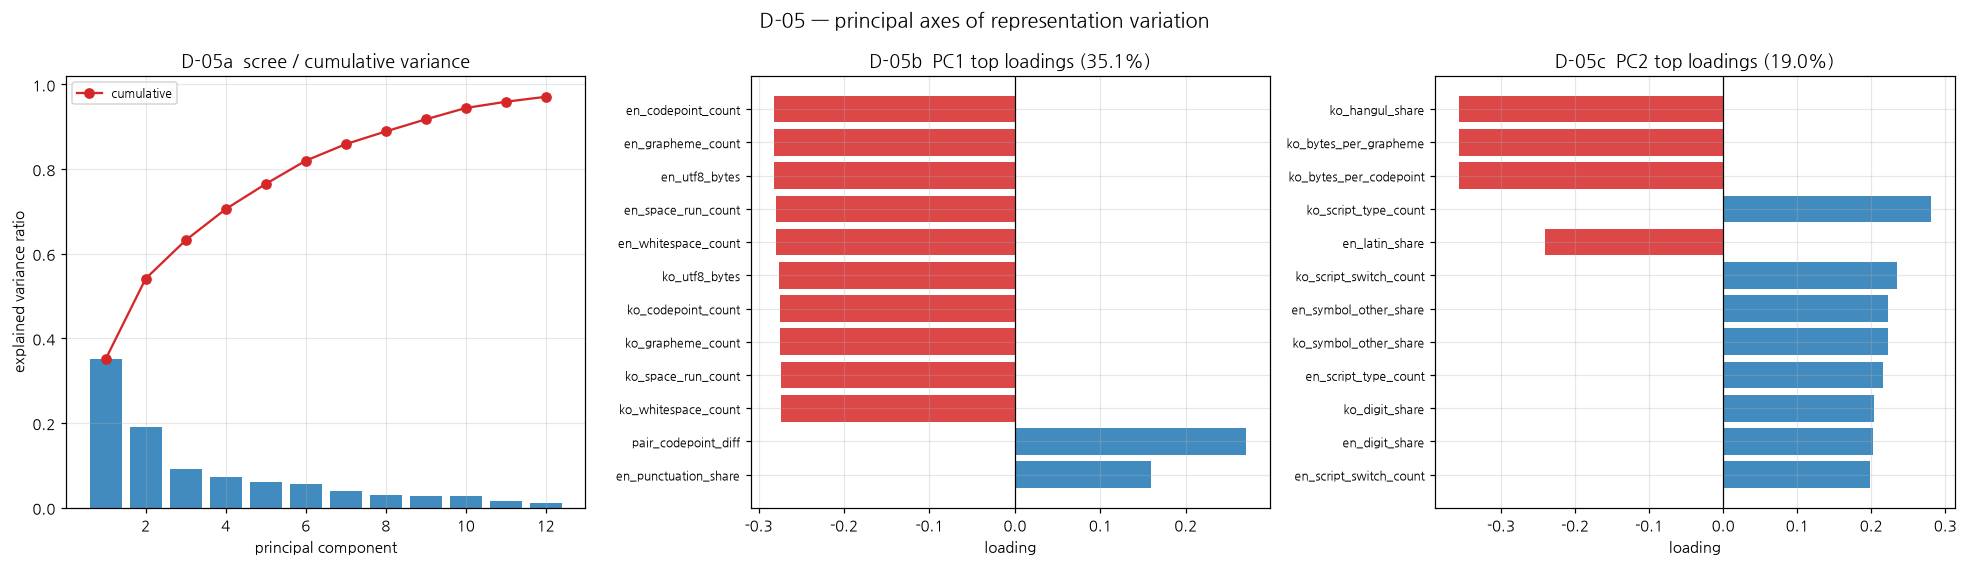

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5.2))
ax[0].bar(range(1, 13), evr[:12], color="tab:blue", alpha=0.85)
ax[0].plot(range(1, 13), np.cumsum(evr[:12]), "o-", color="tab:red", label="cumulative")
ax[0].set(xlabel="principal component", ylabel="explained variance ratio",
          title="D-05a  scree / cumulative variance")
ax[0].legend(fontsize=8)

for k, a in [(0, ax[1]), (1, ax[2])]:
    order = np.argsort(-np.abs(Vt[k]))[:12]
    a.barh(range(len(order)), Vt[k][order][::-1],
           color=["tab:red" if v < 0 else "tab:blue" for v in Vt[k][order][::-1]], alpha=0.85)
    a.set_yticks(range(len(order)))
    a.set_yticklabels([NUMERIC[m] for m in order][::-1], fontsize=8)
    a.axvline(0, color="k", lw=0.8)
    a.set(xlabel="loading", title=f"D-05{'bc'[k]}  PC{k+1} top loadings ({100*evr[k]:.1f}%)")
fig.suptitle("D-05 — principal axes of representation variation", fontsize=13)
ascii_log_ticks(fig)
fig.tight_layout()
plt.show()

## 10 — Director-facing summary

Every statement below is generated from, or directly traceable to, the numbers computed above.

In [24]:
def q(feature, stat):
    return float(dist.loc[feature, stat])


classification = {
    "EXPECTED_STRUCTURE": [
        f"KO is systematically shorter than EN in codepoints: median pair_codepoint_ratio = "
        f"{q('pair_codepoint_ratio','median'):.4f} (KO uses ~{100*q('pair_codepoint_ratio','median'):.0f}% "
        f"of EN codepoints); median KO {q('ko_codepoint_count','median'):.0f} cp vs EN "
        f"{q('en_codepoint_count','median'):.0f} cp.",
        f"KO is systematically LONGER than EN in UTF-8 bytes: median pair_byte_ratio = "
        f"{q('pair_byte_ratio','median'):.4f}. The sign reversal between the two ratios is the "
        f"central structural fact of this cohort.",
        f"KO byte density median {q('ko_bytes_per_codepoint','median'):.4f} B/cp, bounded in "
        f"[{q('ko_bytes_per_codepoint','min'):.2f}, {q('ko_bytes_per_codepoint','max'):.2f}]; EN median "
        f"{q('en_bytes_per_codepoint','median'):.4f}, max {q('en_bytes_per_codepoint','max'):.4f}. "
        f"Both are exactly inside the UTF-8 admissible range.",
        f"pair_codepoint_diff median {q('pair_codepoint_diff','median'):.0f} — KO is shorter by ~39 "
        f"codepoints at the centre of the distribution.",
    ],
    "HEAVY_TAIL_BUT_PLAUSIBLE": [
        f"Length features are right-skewed with finite, corpus-plausible tails: "
        f"ko_codepoint_count p99={q('ko_codepoint_count','p99'):.0f} / max={q('ko_codepoint_count','max'):.0f}; "
        f"en_codepoint_count p99={q('en_codepoint_count','p99'):.0f} / max={q('en_codepoint_count','max'):.0f}.",
        f"pair_codepoint_ratio spans [{q('pair_codepoint_ratio','min'):.4f}, "
        f"{q('pair_codepoint_ratio','max'):.1f}] but p99 is only {q('pair_codepoint_ratio','p99'):.4f}; "
        f"Tukey-outlier prevalence {100*q('pair_codepoint_ratio','tukey_outlier_rate'):.3f}%.",
        f"Sparse share features are zero-inflated by construction, not by error: "
        f"ko_latin_share zero-rate {100*q('ko_latin_share','zero_rate'):.1f}%, "
        f"ko_digit_share {100*q('ko_digit_share','zero_rate'):.1f}%, "
        f"en_hangul_share {100*q('en_hangul_share','zero_rate'):.2f}%.",
    ],
    "BOUNDARY_EXTREME": [
        f"pair_codepoint_ratio >= 2: {int(bnd['pcr_ge_2']):,} rows "
        f"({100*int(bnd['pcr_ge_2'])/EXPECTED_N:.4f}%); >= 10: {int(bnd['pcr_ge_10'])} rows.",
        f"pair_codepoint_ratio < 0.10: {int(bnd['pcr_lt_0_10'])} rows; < 0.05: "
        f"{int(bnd['pcr_lt_0_05'])} rows.",
        f"Ultra-short pairs (<= 3 codepoints on either side): {int(bnd['ko_len_le_3']):,} KO / "
        f"{int(bnd['en_len_le_3']):,} EN — the dominant driver of ratio instability.",
        f"KO with zero Hangul: {int(bnd['ko_zero_hangul']):,}; EN containing Hangul: "
        f"{int(bnd['en_has_hangul']):,} ({100*int(bnd['en_has_hangul'])/EXPECTED_N:.4f}%).",
    ],
    "SUSPICIOUS": [
        f"code_like_flag is a low-specificity surface heuristic in this corpus: "
        f"{100*CODE_LIKE_PARENTHETICAL_SHARE:.1f}% of firings are caused solely by the parenthetical "
        f"pattern \\w+(...) and {100*CODE_LIKE_KEYWORD_SHARE:.1f}% solely by English words that are "
        f"also programming keywords. It reaches {100*CODE_LIKE_TECH_RATE:.1f}% inside "
        f"domain=technology and {100*CODE_LIKE_026_RATE:.1f}% inside corpus 026. Computed correctly "
        f"per its frozen definition; the caveat is the NAME/semantics, and it must not be read as "
        f"'contains source code' downstream.",
        f"domain=technology (N={int(strata_tables['domain'].set_index('level').loc['technology','n']):,}) "
        f"is effectively co-extensive with the known 026 / 특허정보원 biconditional recorded in the SSOT "
        f"redline (N=359,910, exception=0). Any domain effect estimated here is not separable from the "
        f"source effect — this is the already-flagged SSOT §20.2 identifiability warning, restated with "
        f"representation-layer evidence.",
        f"sentence_type is degenerate in the final cohort (single level 'other', N={EXPECTED_N:,}) and "
        f"carries no information as a stratum.",
    ],
    "HARD_INVALID": [],
}
if HARD_INVALID or DEFINITIONAL_VIOLATIONS or NULL_TOTAL or NAN_INF_TOTAL:
    classification["HARD_INVALID"].append(
        f"HARD={HARD_INVALID} DEFINITIONAL={DEFINITIONAL_VIOLATIONS} "
        f"NULL={NULL_TOTAL} NaN/inf={NAN_INF_TOTAL}")

for k, items in classification.items():
    print(f"\n{'='*100}\n{k}  ({len(items)})\n{'='*100}")
    for i, s in enumerate(items, 1):
        print(f"  {i}. {s}")
    if not items:
        print("  (none)")


EXPECTED_STRUCTURE  (4)
  1. KO is systematically shorter than EN in codepoints: median pair_codepoint_ratio = 0.4675 (KO uses ~47% of EN codepoints); median KO 36 cp vs EN 74 cp.
  2. KO is systematically LONGER than EN in UTF-8 bytes: median pair_byte_ratio = 1.1268. The sign reversal between the two ratios is the central structural fact of this cohort.
  3. KO byte density median 2.4500 B/cp, bounded in [1.00, 3.00]; EN median 1.0000, max 2.5088. Both are exactly inside the UTF-8 admissible range.
  4. pair_codepoint_diff median -39 — KO is shorter by ~39 codepoints at the centre of the distribution.

HEAVY_TAIL_BUT_PLAUSIBLE  (3)
  1. Length features are right-skewed with finite, corpus-plausible tails: ko_codepoint_count p99=122 / max=684; en_codepoint_count p99=298 / max=2208.
  2. pair_codepoint_ratio spans [0.0222, 60.0] but p99 is only 0.8333; Tukey-outlier prevalence 2.695%.
  3. Sparse share features are zero-inflated by construction, not by error: ko_latin_share zero-rate 

### The eight diagnostic questions

**1. How do KO and EN length structures differ?**
KO is markedly shorter in *codepoints* and markedly longer in *bytes*. Median KO 36 cp vs EN 74 cp
(`pair_codepoint_ratio` median 0.4675), while median KO 89 B vs EN 74 B (`pair_byte_ratio` median
1.1268). Dispersion is also asymmetric: EN's tail is longer (max 2,208 cp vs KO 684 cp) and EN's
Tukey-outlier prevalence on raw length is ~2.8× KO's (1.06% vs 0.37%). `pair_codepoint_diff` is
centred at −39 with a long left tail (min −2,159) and a short right tail (max +102) — KO is almost
never dramatically longer in codepoints.

**2. What is the range of UTF-8 byte density?**
KO: `[1.000, 3.000]` B/cp, median 2.4500, p1 1.9091, p99 2.6250. The hard ceiling of exactly 3.000 is
pure precomposed Hangul (3 bytes per syllable in UTF-8); values below it are the ASCII spaces,
digits and punctuation mixed into Korean text. EN: `[1.000, 2.509]`, median exactly 1.0000, p99
1.0000 — EN is ASCII to the 99th percentile, with only 21,885 rows (0.57%) containing any
non-ASCII byte at all. Every observed value is inside the arithmetically admissible UTF-8 band.

**3. Where are the centre and tails of the pair ratios?**
`pair_codepoint_ratio`: median 0.4675, IQR 0.1300 (p25 0.4083 → p75 0.5383), p99 0.8333, and only 458
rows (0.012%) at or above parity-doubling (≥ 2). `pair_byte_ratio`: median 1.1268, p99 1.9697, max
144. Both are tightly concentrated with thin, sparse tails; the *body* of the distribution is where
essentially all the mass lives.

**4. Which feature has the strongest outlier behaviour?**
By Tukey prevalence, the sparse share features dominate — `ko_digit_share` 22.9%,
`ko_script_type_count` / `ko_script_switch_count` 22.3%, `en_digit_share` 19.5%, `ko_latin_share`
15.4%. This is an artefact of zero-inflation (a feature that is 0 for 77–93% of rows has IQR 0, so
any non-zero value exceeds the fence) rather than genuine anomaly, and the Tukey fence is simply the
wrong instrument for them. Among the *continuous* features, `pair_codepoint_ratio` (2.70%) and
`pair_byte_ratio` (2.50%) carry the highest genuine outlier load, and by extremity of magnitude
`pair_byte_ratio` is the most extreme feature in the layer (max 144 against a median of 1.13, i.e.
~128× the centre).

**5. Where do extremes concentrate?**
Overwhelmingly at **short length**. `length_stratum` Q1 carries a 9.20% outlier rate against 0.05% in
Q5 — a ~184× gradient, monotone decreasing in length (Q1 9.20 → Q2 1.74 → Q3 0.75 → Q4 0.66 → Q5
0.05). By domain: `general` 5.43% and `dialogue` 3.38% versus `technology` 0.31%. By corpus: `025`
3.77% versus `026` 0.71%. Direction is nearly neutral (KO_TO_EN 2.88% vs EN_TO_KO 2.34%).

The human N=500 audit also placed 20 of its 25 confirmed failures in Q1/Q4/Q5, but that is **not**
corroboration of the result above and must not be read as such. The two are different measurements
on different designs: this is a full-population geometric outlier rate on a ratio feature, whereas
the audit is a 500-row seeded sample scored for *semantic* correspondence, with its own allocation
across strata. They share a stratum label and nothing else — no common estimand, denominator, or
sampling frame — so agreement between them is an observation to be explained, not evidence.

**6. Which features are redundant?**
62 pairs exceed |ρ| ≥ 0.90. Four groups show *near-deterministic redundancy* — they agree on all
but a handful of rows — and should not enter the same model together:

| group | evidence |
|---|---|
| `grapheme_count` ≈ `codepoint_count` | ρ = 1.000000; differs in 29 KO / 17 EN rows of 3.8 M |
| `pair_grapheme_ratio` ≈ `pair_codepoint_ratio` | ρ = 1.000000; differs in 43 rows |
| `space_run_count` ≈ `whitespace_count` | ρ = 1.000000; differs in 26 rows per side |
| `bytes_per_grapheme` ≈ `bytes_per_codepoint` | ρ = 1.000000 (KO), 0.999972 (EN) |

Additionally `en_utf8_bytes` ≈ `en_codepoint_count` (ρ = 0.999989, differing in 0.57% of rows) and
`ko_bytes_per_codepoint` ≈ `ko_hangul_share` (ρ = 0.999519) — the latter is not a coding bug but the
mechanical consequence of Hangul being the only 3-byte script present, so KO byte density is almost a
linear re-expression of Hangul share. The whole length block (`ko/en × {codepoint, grapheme, byte,
whitespace, space_run}`) is mutually correlated at ρ ≈ 0.93–1.00. **None of this is acted on here**;
it is input to the G5 collinearity/identifiability gate.

**7. Which extremes are real linguistic/surface structure rather than error?**
- The KO byte-density ceiling at exactly 3.000 B/cp — pure precomposed Hangul, definitionally correct.
- EN byte density pinned at exactly 1.000 through p99 — EN is genuinely ASCII prose.
- `pair_codepoint_ratio ≥ 2` (458 rows): short KO against *even shorter*, punctuation-rich EN — the
  abbreviation/acronym/symbol-answer pattern.
- `pair_codepoint_ratio < 0.10` (54 rows): condensed KO against long EN.
- `ko_script_type_count ∈ {2, 3}` in 22.3% of rows — Korean text routinely embeds Latin and symbols;
  this is normal mixed-script Korean, not corruption.
- `script_type_count = 0` (183 KO / 217 EN) — texts that are entirely digits/punctuation/whitespace.
  Legal by construction; worth watching downstream because their ratios are the least stable.

The genuinely *cautionary* items are not extremes at all: the `code_like_flag` semantics (§7) and the
`technology`↔`026` identifiability collapse (§6).

**8. Which representation region deserves particular attention in TP / decomposition work?**
PCA on the standardised features gives a clean three-axis picture (PC1–PC3 = 63.2% of variance):

- **PC1 (35.1%) — joint length.** Loads almost uniformly on all KO and EN length measures
  (|loadings| ≈ 0.27–0.28). This is the axis `CodePointRatio` will mostly *not* see, because it is a
  ratio.
- **PC2 (19.0%) — KO script composition / byte density.** `ko_hangul_share` and
  `ko_bytes_per_codepoint` (−0.357/−0.356) opposed to `ko_script_type_count` and
  `ko_script_switch_count` (+0.281/+0.235). This axis is the direct structural antecedent of
  **`ByteDensityRatio`**.
- **PC3 (9.1%) — pair ratio.** `pair_codepoint_ratio` / `pair_grapheme_ratio` / `pair_byte_ratio`
  (−0.469/−0.469/−0.455) — the axis that *is* the decomposition's first two terms.

Concretely, three regions should be watched when NB05/NB07 run:

1. **The short-length region (`length_stratum` Q1, ≈ 840 k pairs).** It holds ~9% Tukey outliers,
   nearly all the ratio instability of the representation features, and both extreme tails.
   No token count has been measured yet, so nothing is claimed about `logTP` here. What the
   representation layer supports is a **candidate for future diagnosis**: because these pairs are
   short, a one-token difference moves any token ratio by a large relative amount, so Q1 is where
   `logTP` dispersion should be examined first once NB05 has produced token counts.
2. **The high-Hangul-purity band (`ko_bytes_per_codepoint` → 3.000).** Along PC2 this is where
   `ByteDensityRatio` is maximal, so under IR-01 it is the region where byte-representation effects
   must be reported *separately* from tokenizer compression effects.
3. **The mixed-script / high-switch region (`ko_script_type_count ≥ 2`, 22.3%; `switch ≥ 6`, 1.1%).**
   This notebook has not inspected the o200k `pat_str`, so no claim is made about where that regex
   actually splits. The measured fact is only that script alternation is frequent and unevenly
   distributed. Whether script boundaries coincide with regex chunk boundaries, and whether that
   shows up in `CompressionPenalty`, is a **hypothesis for NB06's regex chunk audit to test** —
   stated here so NB06 has a pre-registered place to look, not asserted as a finding.

## 11 — Manifest

A tracked aggregate manifest is emitted. It contains counts, rates, quantiles, correlations and
provenance hashes only — no raw text, no `pair_id` lists, no recoverable content.

In [25]:
POST = resource_snapshot("post_eda")
MANIFEST_PATH = PROJECT_ROOT / "outputs" / "manifests" / "REPRESENTATION_EDA_MANIFEST_v001.json"


def json_default(obj):
    'numpy/pandas scalar를 JSON 직렬화 가능한 python scalar로 변환한다.'
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        v = float(obj)
        return v if np.isfinite(v) else None
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"not JSON serialisable: {type(obj)}")

payload = {
    "artifact_id": "REPRESENTATION_EDA_MANIFEST_v001",
    "notebook": "notebooks/exploratory/03_representation_feature_diagnostics.ipynb",
    "run_id": RUN_ID,
    "run_mode": "EXPLORATORY_DIAGNOSTIC",
    "notebook_role": "AUXILIARY_DIAGNOSTIC_NOT_CANONICAL_NB07",
    "canonical_figure_ids_used": False,
    "authority": {
        "ssot": "KOEN-TP-RS-001 / Korean_English_Tokenization_Premium_Research_Spec_v1.0",
        "sections": ["§8", "§12.2 D-02", "§16", "§20.2", "§31"],
        "final_cohort_directive": "ssot/HumanLebeled/KOEN_G1_HUMAN_AUDIT_FINAL_ADJUDICATION.md",
    },
    "input": {
        "rep_features": {"path": "data/registry/REP_FEATURES_v001.parquet",
                         "sha256": integrity["REP_FEATURES_v001.parquet"]["sha256"]},
        "pair_registry": {"path": "data/registry/PAIR_REGISTRY_v002.parquet",
                          "sha256": integrity["PAIR_REGISTRY_v002.parquet"]["sha256"]},
        "row_count": int(n_rows), "distinct_pair_id": int(n_distinct),
        "column_count": len(COLUMNS),
        "g1_excluded_pair_ids_present": int(n_excluded_present),
    },
    "compute_policy": {
        "full_population_engine": f"duckdb {duckdb.__version__} (parquet projection/predicate pushdown)",
        "duckdb_memory_limit_gib": DUCKDB_MEM_GIB, "duckdb_threads": DUCKDB_THREADS,
        "spill_directory": str(SPILL_DIR.relative_to(PROJECT_ROOT)),
        "deterministic_sample_key": f"md5(pair_id || '{SAMPLE_SALT}')",
        "sample_n": int(len(SAMPLE)), "pca_n": int(len(X)),
        "pandas_full_load_of_population": False,
    },
    "resources": {"pre": PRE, "post": POST, "verdict": VERDICT},
    "validity": {
        "hard_invalid_total": HARD_INVALID,
        "definitional_violation_total": DEFINITIONAL_VIOLATIONS,
        "null_total": NULL_TOTAL, "nan_inf_total": NAN_INF_TOTAL,
        "rules_evaluated": len(rules),
        "implementation_defect": 0 if (HARD_INVALID == 0 and DEFINITIONAL_VIOLATIONS == 0) else 1,
        "per_rule": validity.to_dict(orient="records"),
        "null_inventory": null_inventory,
        "naive_rule_note": ("naive 'sum(shares)=1' and 'script_type_count>=1' forms are "
                            "mis-specifications; the frozen definitions imply "
                            "'sum(shares)+whitespace_density=1' and a biconditional on "
                            "{hangul,latin,other} presence, both of which hold with 0 violations"),
    },
    "distribution_profile": dist.reset_index().to_dict(orient="records"),
    "boundary_counts": {k: int(bnd[k]) for k in bnd.index},
    "strata": {st: strata_tables[st].to_dict(orient="records") for st in STRATUM_COLS},
    "degenerate_strata": DEGENERATE,
    "surface_structure": {k: float(surface[k]) for k in surface.index[1:]},
    "special_expression_flags": {k: float(flags[k]) for k in flags.index},
    "code_like_flag_specificity": {
        "inspected_flagged_sides": int(inspected),
        "matches": {k: int(v) for k, v in matches.items()},
        "sole_cause": {k: int(v) for k, v in sole_cause.items()},
        "verdict": "LOW_SPECIFICITY_SURFACE_HEURISTIC_NOT_A_CODE_DETECTOR",
    },
    "redundancy": {
        "rho_threshold": RHO_THRESHOLD,
        "pearson_basis": "full_population",
        "spearman_basis": f"deterministic_sample_n={len(SAMPLE)}",
        "pair_count": int(len(redundant)),
        "pairs": redundant.to_dict(orient="records"),
        "named_relationships": named.to_dict(orient="records"),
        "exact_equality_audit": exact_dup.to_dict(orient="records"),
        "note": "diagnostic only — NOT a G5 collinearity PASS; no feature is dropped here",
    },
    "pca": {"n": int(len(X)), "p": len(NUMERIC),
            "explained_variance_ratio": [float(v) for v in evr],
            "top_loadings": pca_loadings},
    "director_summary": classification,
    "gate_claims": {
        "G2_representation_integrity": "NOT_CLAIMED — research adjudication (Claude-B)",
        "G5_collinearity": "NOT_CLAIMED — diagnostic redundancy only",
        "canonical_nb07": "NOT_PERFORMED",
    },
    "downstream_authorization": {
        "hard_invalid": HARD_INVALID,
        "implementation_defect": 0 if (HARD_INVALID == 0 and DEFINITIONAL_VIOLATIONS == 0) else 1,
        "condition_a_full_kiwi_and_o200k": (HARD_INVALID == 0 and DEFINITIONAL_VIOLATIONS == 0),
        "condition_b_morphology_full_run_authorized": "PENDING_CLAUDE_B",
        "note": "Condition A is satisfied by this notebook. Full Kiwi / full o200k additionally "
                "require Claude-B's MORPHOLOGY_FULL_RUN_AUTHORIZED verdict.",
    },
    "start_kst": PRE["timestamp_kst"], "end_kst": POST["timestamp_kst"],
    "status": "EXPLORATORY_DIAGNOSTIC_COMPLETE",
}

MANIFEST_PATH.write_text(
    json.dumps(payload, ensure_ascii=False, indent=2, sort_keys=True, default=json_default) + "\n",
    encoding="utf-8")
print(f"wrote {MANIFEST_PATH.relative_to(PROJECT_ROOT)}  "
      f"({MANIFEST_PATH.stat().st_size:,} bytes)")
print(f"manifest sha256 {sha256_file(MANIFEST_PATH)}")
print(f"\nHARD_INVALID          = {HARD_INVALID}")
print(f"IMPLEMENTATION_DEFECT = {payload['validity']['implementation_defect']}")
print(f"resource verdict      = {VERDICT}  "
      f"(pre {PRE['ram_available_gib']} GiB -> post {POST['ram_available_gib']} GiB available)")
con.close()

wrote outputs/manifests/REPRESENTATION_EDA_MANIFEST_v001.json  (106,246 bytes)
manifest sha256 80f2cb8a73c748b975bb1d1d758bb814e464580f36aa9fd18f4bf7f0c2bea052

HARD_INVALID          = 0
IMPLEMENTATION_DEFECT = 0
resource verdict      = RESOURCE_OK  (pre 10.64 GiB -> post 9.31 GiB available)


---

## Stop point

```
HARD_INVALID           = 0
IMPLEMENTATION_DEFECT  = 0
```

Condition A for the full Kiwi and full o200k population runs is therefore satisfied by this
notebook. Those runs additionally require Claude-B's `MORPHOLOGY_FULL_RUN_AUTHORIZED` verdict from
the independent 85-row morphology sanity review. **This notebook authorizes nothing on its own and
starts no population job.**

Local-only, never committed: `.runtime/rep-eda/**` (stratum sidecar, DuckDB spill).
Tracked: this notebook and `outputs/manifests/REPRESENTATION_EDA_MANIFEST_v001.json`.